# POD RBF : étude sur les différentes manière d'impplémentation de cette méthode sur les 32 tempêtes géomagéntiques

## Extraction des données

In [2]:
import time as tm
import numpy as np
from datetime import datetime
import os
import sys

# Importation de la configuration des chemins
ROOT_DIR = "/gpfs/users/godardc/hinge/Donnees_Guillaume_path"
#/gpfs/users/godardc/hinge/Donnees_Guillaume_path
import pandas as pd

In [3]:
num_storm = 30
fichier_obs_path = f"/gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/test_constantin/Entrainement_RNN/32STORMS_DATA/HSS{num_storm}.dat"
data = np.loadtxt(fichier_obs_path)

In [4]:
num_storm = 30
fichier_obs_path = f"/gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/test_constantin/Entrainement_RNN/32STORMS_DATA/HSS{num_storm}.dat"
data = np.loadtxt(fichier_obs_path)
df = pd.DataFrame(data, columns=['Kp','t','L','alpha','E','Daa'])
df[['Kp','t','L']] = df[['Kp','t','L']].astype(int)

all_t = sorted(df.t.unique())
alpha_vals = sorted(df.alpha.unique())
E_vals = sorted(df.E.unique())

n_t = len(all_t)
n_alpha = len(alpha_vals)
n_E = len(E_vals)

alpha_grid, E_grid = np.meshgrid(alpha_vals, E_vals, indexing='ij')
grid_points = np.column_stack((alpha_grid.ravel(), 10**E_grid.ravel()))

In [5]:
def_range = df[(df['L']==3)&(df['t']==11)]
def_range

,Kp,t,L,alpha,E,Daa
167347,3,11,3,10.451517,-1.132746,-10.509956
167348,3,11,3,10.451517,-0.881499,-9.353029
167349,3,11,3,10.451517,-0.698900,-7.152399
167350,3,11,3,10.451517,-0.557853,-6.726801
167351,3,11,3,10.451517,-0.444301,-6.539062
...,...,...,...,...,...,...
182569,3,11,3,89.558073,0.746504,-10.832482
182570,3,11,3,89.558073,0.754587,-10.839247
182571,3,11,3,89.558073,0.762524,-10.844272
182572,3,11,3,89.558073,0.770318,-10.844022


### Complétion des données manquantes dans chaque snapshot

Chaque tempête géomagnétique (ou **HSS** pour *High Speed Storm*) contient un certain nombre de snapshots, 
qui dépendent du temps \( t \) (allant de **10** à **18**) et des **L-shells** (allant de **2** à **5**).  
On peut par exemple les visualiser sous la forme d'une matrice binaire.  
Voici un exemple pour la **HSS 3** :

|   | 10 | 11 | 12 | 13 | 14 | 15 | 16 | 17 | 18
----|----|----|----|----|----|----|----|----|----
| 2 |  1 |  1 |  1 |  1 |  1 | 1  | 1  | 1  |  1
| 3 |  1 |  1 |  1 |  1 |  1 | 1  | 1  | 1  |  1
| 4 |  0 |  1 |  1 |  1 |  1 | 0  | 1  | 1  |  1
| 5 |  0 |  0 |  0 |  0 |  0 | 0  | 1  | 0  |  1


Chaque snapshot (représenté ici par un **1**) correspond à une fonction 2D du coefficient de diffusion 
$D_{\alpha\alpha}$, dépendant de l’angle $\alpha$ et de l’énergie $E$.  
- $\alpha$ contient entre **254 et 256** valeurs selon la L-shell,  
- $E$ contient toujours **60** valeurs.  

Cela représente donc **15 240 valeurs** de $D_{\alpha\alpha}$ pour chaque snapshot.

Cependant, certaines valeurs peuvent manquer pour certains snapshots.  
Il faut alors les **interpoler linéairement** afin d’obtenir un mapping complet de 15 240 valeurs.  
C’est précisément ce que fait la fonction **`remplissage()`**.  

Chaque matrice complète de taille **(15 240, 9)** est ensuite sauvegardée via la fonction **`process_storm()`**, 
afin d’éviter de saturer la mémoire RAM.


#### Fonction **`remplissage()`**

In [111]:
import numpy as np
import pandas as pd
from itertools import product


num_storm = 30
fichier_obs_path = f"/gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/test_constantin/Entrainement_RNN/32STORMS_DATA/HSS{num_storm}.dat"
data = np.loadtxt(fichier_obs_path)
df = pd.DataFrame(data, columns=['Kp','t','L','alpha','E','Daa'])
df[['Kp','t','L']] = df[['Kp','t','L']].astype(int)


# fonction utilitaire nearest neighbor
def nearest_value(a, e, df):
    if df.empty or df['Daa'].dropna().empty:
        return np.nan  # ou une autre valeur par défaut
    d = np.sqrt((df['alpha'] - a)**2 + (df['E'] - e)**2)
    return df.loc[d.idxmin(), 'Daa']


def remplissage(sous_df,df):
    # sous_df déjà défini : df[(df['L']==2)&(df['t']==11)]
    sous_df = sous_df.copy()  # ou réutiliser votre sous_df

    # vecteurs triés de alpha et E
    def_range = df[(df['L']==3)&(df['t']==11)]
    alphas = np.sort(def_range['alpha'].unique())
    Es = np.sort(def_range['E'].unique())

    # grille complète attendue
    full = pd.DataFrame(list(product(alphas, Es)), columns=['alpha', 'E'])

    # merge pour récupérer Daa quand présent
    merged = full.merge(sous_df[['alpha', 'E', 'Daa']], on=['alpha', 'E'], how='left')

    
    # interpolation pour chaque point manquant
    missing_idx = merged[merged['Daa'].isna()].index
    for idx in missing_idx:
        a = merged.at[idx, 'alpha']
        e = merged.at[idx, 'E']

        # essai 1 : interpolation le long de E (fixe alpha)
        grp_E = sous_df[sous_df['alpha'] == a].sort_values('E')
        if len(grp_E) >= 2 and (e >= grp_E['E'].min()) and (e <= grp_E['E'].max()):
            merged.at[idx, 'Daa'] = np.interp(e, grp_E['E'].values, grp_E['Daa'].values)
            continue

        # essai 2 : interpolation le long de alpha (fixe E)
        grp_a = sous_df[sous_df['E'] == e].sort_values('alpha')
        if len(grp_a) >= 2 and (a >= grp_a['alpha'].min()) and (a <= grp_a['alpha'].max()):
            merged.at[idx, 'Daa'] = np.interp(a, grp_a['alpha'].values, grp_a['Daa'].values)
            continue

        # essai 3 : voisin le plus proche (fallback)
        val = nearest_value(a, e, sous_df)
        if pd.isna(val):
            merged.at[idx, 'Daa'] = 0  # ou une valeur par défaut
        else:
            merged.at[idx, 'Daa'] = val


    # contrôle : combien ont été remplis
    n_remplis = merged['Daa'].isna().sum()

    # pivot en matrice (alpha en index, E en colonnes) et conversion numpy
    pivot = merged.pivot(index='alpha', columns='E', values='Daa').sort_index(axis=0).sort_index(axis=1)
    matrice = pivot.values  # numpy array

    # matrice correspond à : lignes = alphas triés, colonnes = Es triés
    return matrice.ravel()

#### Fonction **`process_storm()`**

In [112]:
import os
import numpy as np
import gc

SAVE_DIR = "SVD_tempêtes_L2"
os.makedirs(SAVE_DIR, exist_ok=True)

def process_storm(num_storm):
    fichier_obs_path = f"/gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/test_constantin/Entrainement_RNN/32STORMS_DATA/HSS{num_storm}.dat"
    data = np.loadtxt(fichier_obs_path)
    df = pd.DataFrame(data, columns=['Kp','t','L','alpha','E','Daa'])
    df[['Kp','t','L']] = df[['Kp','t','L']].astype(int)

    # Pré-allocation de la matrice
    sous_df = df[(df['L']==3) & (df['t']==10)]
    num_points = len(remplissage(sous_df, df))
    num_snapshots = 9
    snapshots_matrix = np.empty((num_points, num_snapshots), dtype=np.float32)

    for i, t_val in enumerate(range(10,19)):
        snapshot1 = df[(df['L'] == 3) & (df['t'] == t_val)]
        snapshots_matrix[:, i] = remplissage(snapshot1, df).astype(np.float32)

    # Sauvegarde compressée de la matrice pour cette tempête
    np.savez_compressed(os.path.join(SAVE_DIR, f"storm{num_storm}_matrix_L3.npz"),
                        snapshots_matrix=snapshots_matrix)

    print(f"storm{num_storm}_matrix_L3.npz saved in {SAVE_DIR}")
    del df, snapshots_matrix
    gc.collect()


In [8]:
for i in range(32) :
    process_storm(i)
    print("Terminé \n ---------------")


storm0_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm1_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm2_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm3_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm4_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm5_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm6_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm7_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm8_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm9_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------
storm10_matrix_L3.npz saved in SVD_tempêtes_L3
Terminé 
 ---------------


ValueError: You are trying to merge on object and float64 columns. If you wish to proceed you should use pd.concat

### Extraction des ratios d’énergie grâce à <code>scrap()</code>

Dans cette étape, on effectue une **décomposition en modes propres (POD)** pour **chaque tempête**.  
Pour chaque décomposition, on calcule le **pourcentage d'information** représenté par chaque **sous-espace propre** (ou mode).  

Les résultats — c’est-à-dire les ratios d’énergie cumulés — sont ensuite sauvegardés dans le dossier : **`SVD_energy_ratio/`**

Ce dossier contient donc, pour chaque tempête, les valeurs indiquant la part d’énergie expliquée par les différents modes issus de la POD.


In [85]:
Energy_save_dir = "SVD_energy_ratio"
os.makedirs(Energy_save_dir, exist_ok=True)
SAVE_DIR = "SVD_tempêtes_L2"

import os
import numpy as np
import gc

def scrap():
    for storm in range(32):
        data = np.load(os.path.join(SAVE_DIR, f"storm{storm}_matrix_L2.npz"))
        snapshots_matrix = data['snapshots_matrix']

        # SVD
        U, D, Vt = np.linalg.svd(snapshots_matrix.T, full_matrices=False)

        # Ratios d'énergie
        ratios = [np.sum(D[:i+1]**2) / np.sum(D**2) for i in range(D.size)]      

        # Sauvegarde ratios
        np.savez_compressed(os.path.join(Energy_save_dir, f"storm{storm}_energy_ratio_L2.npz"),
                            ratios=ratios)
        


        del snapshots_matrix, U, D, Vt
        gc.collect()
scrap()


In [16]:
for storm in range(32):
    data = np.load(os.path.join(SAVE_DIR, f"storm{storm}_matrix_L2.npz"))
    snapshots_matrix = data['snapshots_matrix']

    print(f"Storm {storm} : {snapshots_matrix.shape}")

Storm 0 : (15240, 9)
Storm 1 : (15240, 9)
Storm 2 : (15240, 9)
Storm 3 : (15240, 9)
Storm 4 : (15240, 9)
Storm 5 : (15240, 9)
Storm 6 : (15240, 9)
Storm 7 : (15240, 9)
Storm 8 : (15240, 9)
Storm 9 : (15240, 9)
Storm 10 : (15240, 9)
Storm 11 : (15240, 9)
Storm 12 : (15240, 9)
Storm 13 : (15240, 9)
Storm 14 : (15240, 9)
Storm 15 : (15240, 9)
Storm 16 : (15240, 9)
Storm 17 : (15240, 9)
Storm 18 : (15240, 9)
Storm 19 : (15240, 9)
Storm 20 : (15240, 9)
Storm 21 : (15240, 9)
Storm 22 : (15240, 9)
Storm 23 : (15240, 9)
Storm 24 : (15240, 9)
Storm 25 : (15180, 9)
Storm 26 : (15180, 9)
Storm 27 : (15240, 9)
Storm 28 : (15240, 9)
Storm 29 : (15180, 9)
Storm 30 : (15180, 9)
Storm 31 : (15180, 9)


## Application de la POD sur l'ensemble des 32 tempêtes
Dans cette section, au lieu de faire une SVD sur chaque tempête à L fixé, on effectue la SVD sur l'ensemble des tempêtes. <br>

Au lieu d'avoir 9 sous espaces propres par tempête qui sont propres à chaque tempêtes, on en a donc 288 propres correspondant à toutes les tempêtes. <br>
À noter qu'on fait toujours ça à L fixé, (et pour L = 2 et L = 3 voir la partie Fonction **'remplissage()'**)

### SVD sur l'ensemble des points pour un L fixé
On considère une matrice contenant l'enesmble des points de tous les snapshots de toutes les tempêtes pout L = 2. <br>
On a donc une matrice de taille (485760, 9) <br>

In [17]:
import numpy as np
import os
import gc

SAVE_DIR = "SVD_tempêtes_L2"  
OUTPUT_DIR = "Global_SVD"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def build_big_snapshot_matrix(L=2):
    all_matrices = []
    min_rows = 15180 

    for storm in range(32):
        file_path = os.path.join(SAVE_DIR, f"storm{storm}_matrix_L{L}.npz")
        if not os.path.exists(file_path):
            print(f"Fichier manquant pour storm {storm}")
            continue

        data = np.load(file_path)
        snapshots_matrix = data['snapshots_matrix']

        # Tronquer si besoin
        if snapshots_matrix.shape[0] > min_rows:
            snapshots_matrix = snapshots_matrix[:min_rows, :]

        elif snapshots_matrix.shape[0] < min_rows:
            print(f"Attention : storm {storm} plus court ({snapshots_matrix.shape[0]} lignes)")
            continue  # on peut aussi choisir de le sauter

        all_matrices.append(snapshots_matrix)
        del snapshots_matrix, data
        gc.collect()

    # Concaténation verticale : toutes les tempêtes l'une à la suite de l'autre
    big_snapshot_matrix = np.vstack(all_matrices)
    print(f"Big snapshot matrix shape : {big_snapshot_matrix.shape}")

    # Sauvegarde
    out_path = os.path.join(OUTPUT_DIR, f"big_snapshot_matrix_L{L}.npz")
    np.savez_compressed(out_path, big_snapshot_matrix=big_snapshot_matrix)
    print(f"Sauvegardé sous {out_path}")

    return big_snapshot_matrix



In [18]:
# Création et SVD
big_matrix = build_big_snapshot_matrix(L=2)
U, D, Vt = np.linalg.svd(big_matrix.T, full_matrices=False)
np.savez_compressed(os.path.join(OUTPUT_DIR, "SVD_big_snapshot_L2.npz"), U=U, D=D, Vt=Vt)
print("SVD terminée et sauvegardée.")

Big snapshot matrix shape : (485760, 9)
Sauvegardé sous Global_SVD/big_snapshot_matrix_L2.npz
SVD terminée et sauvegardée.


In [21]:
print(f"U dimensions : {U.shape}")
print(f"D dimensions : {D.shape}")
print(f"Vt dimensions : {Vt.shape}")
# Ratios d'énergie
ratios = [np.sum(D[:i+1])/np.sum(D) for i in range(D.size)]
ratios


U dimensions : (9, 9)
D dimensions : (9,)
Vt dimensions : (9, 485760)


[0.80514073,
 0.83854383,
 0.86798656,
 0.89666575,
 0.9219087,
 0.94294226,
 0.9636172,
 0.98248935,
 1.0]

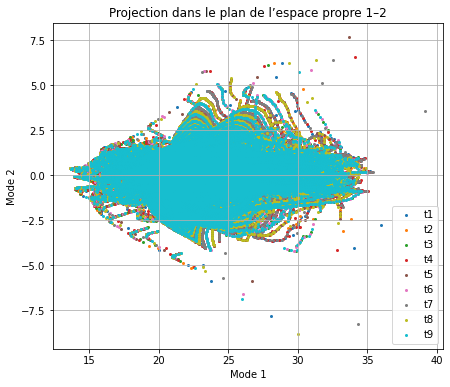

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Chargement des résultats de la SVD
data = np.load(os.path.join(OUTPUT_DIR, "SVD_big_snapshot_L2.npz"))
U, D, Vt = data["U"], data["D"], data["Vt"]

# Coordonnées dans l’espace propre 1–2
X = D[0] * Vt[0, :]
Y = D[1] * Vt[1, :]

n_t = 9  # nombre de temps par tempête
n_storms = X.size // n_t

colors = plt.cm.tab10(np.linspace(0, 1, n_t))

plt.figure(figsize=(7,6))
for i in range(n_t):
    plt.scatter(
        X[i::n_t],
        Y[i::n_t],
        s=4,
        color=colors[i],
        label=f"t{i+1}"
    )

plt.xlabel("Mode 1")
plt.ylabel("Mode 2")
plt.title("Projection dans le plan de l’espace propre 1–2")
plt.legend()
plt.grid(True)
plt.show()


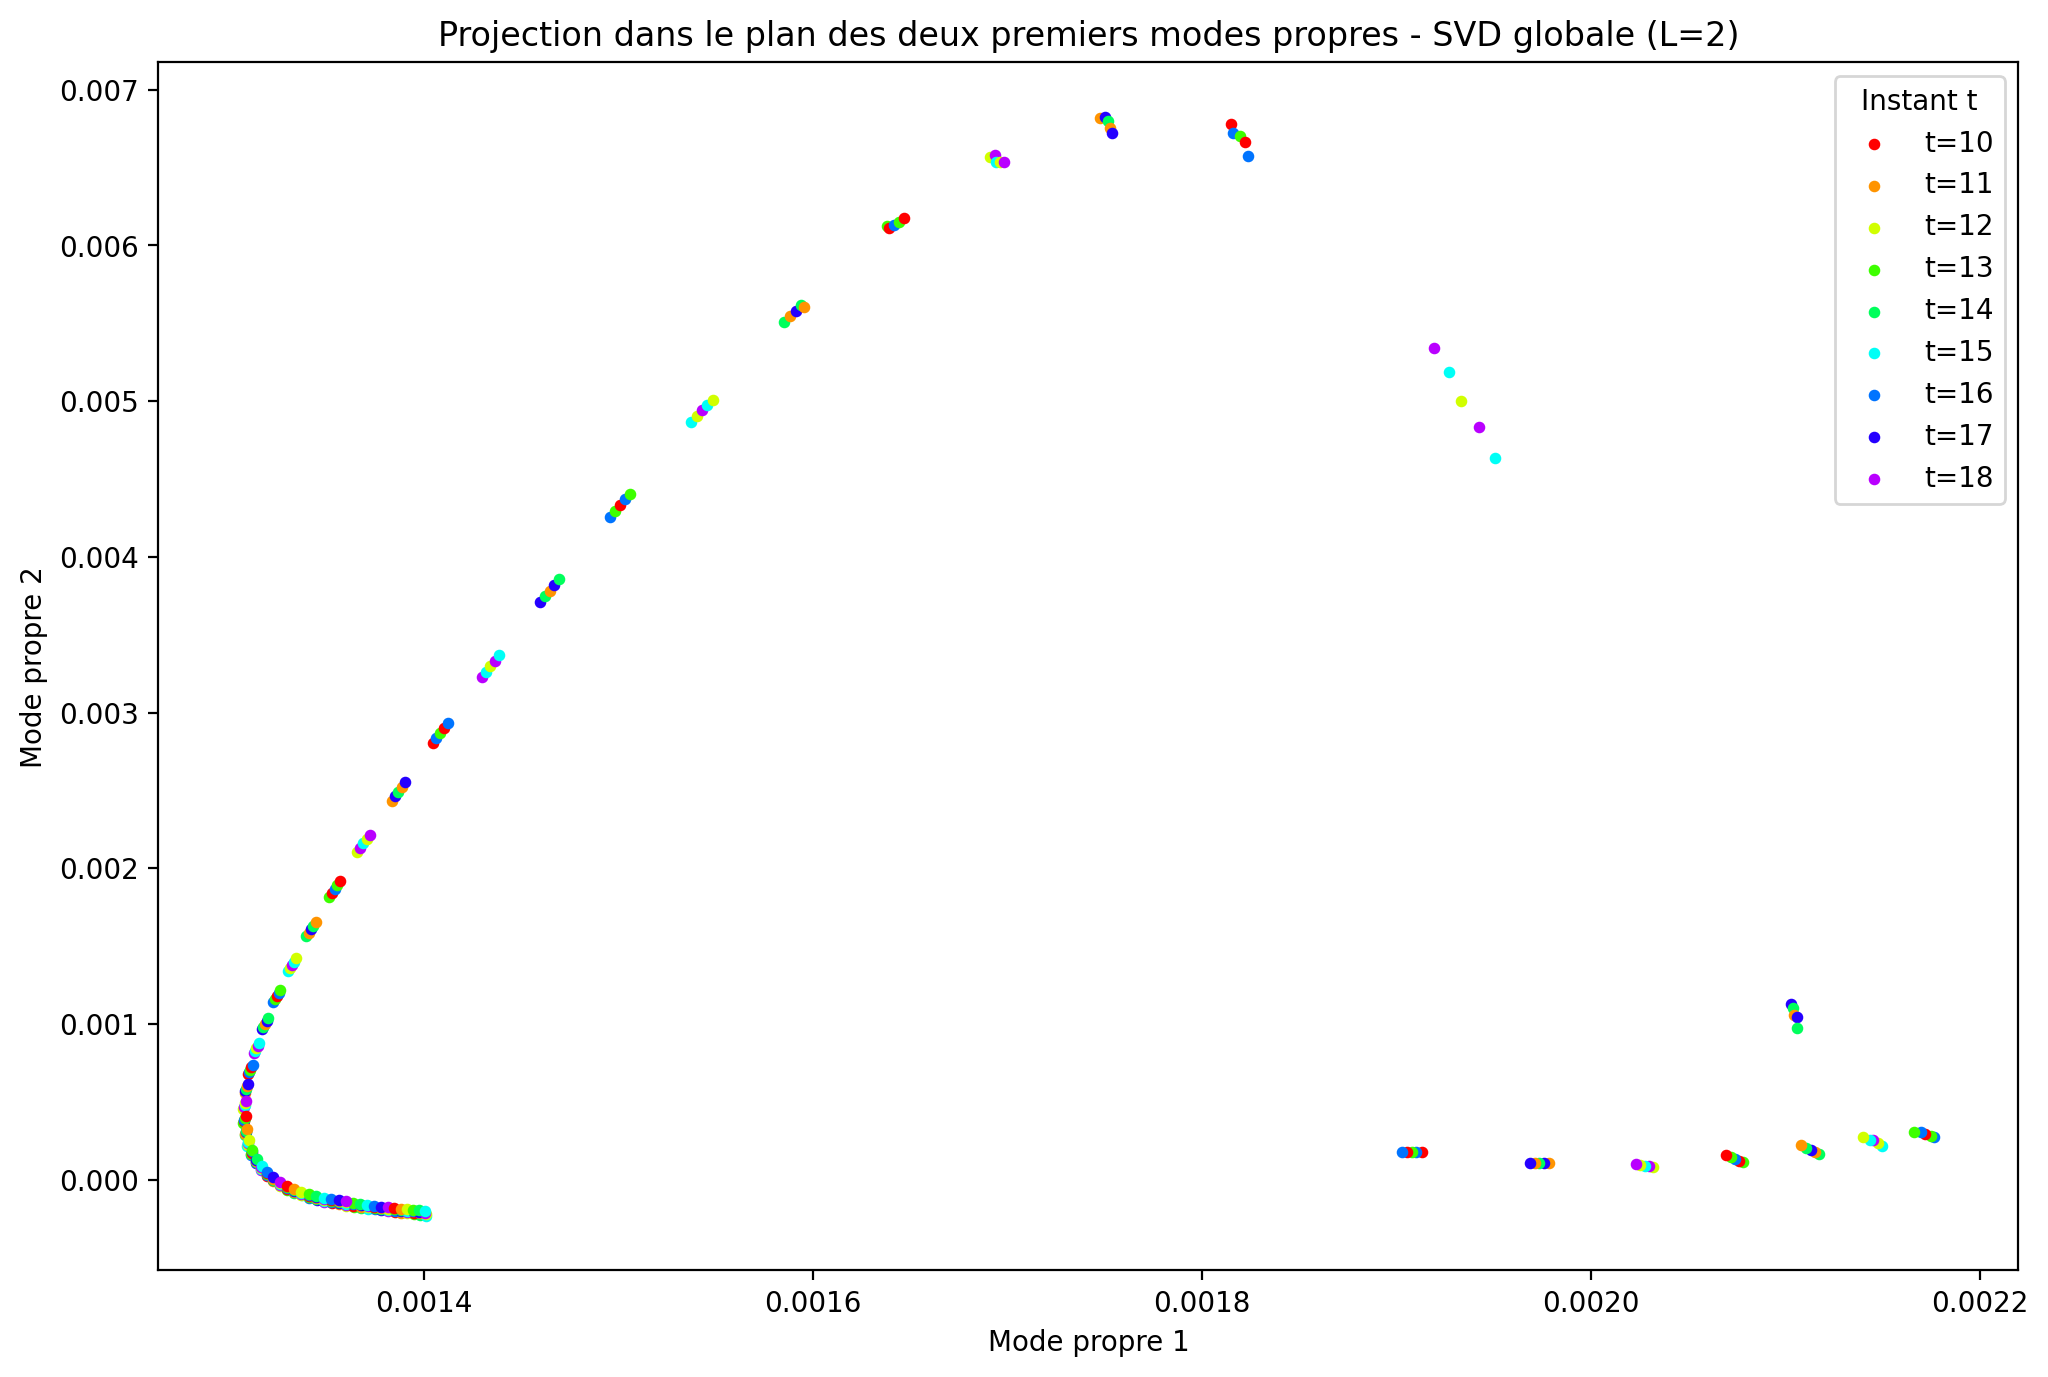

288


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Chargement de la SVD globale
data = np.load(os.path.join(OUTPUT_DIR, "SVD_big_snapshot_L2.npz"))
U, D, Vt = data["U"], data["D"], data["Vt"]

# Palette de couleurs pour les 9 instants t = 10..18
colors = plt.cm.hsv(np.linspace(0, 0.8, 9))

plt.figure(figsize=(12,8), dpi=200)

# On sait que pour chaque tempête, il y a 9 snapshots consécutifs
n_snapshots_per_storm = 9
n_storms = 32

# Vt contient les coefficients temporels (chaque colonne = snapshot)
# On projette sur les 2 premiers modes propres
proj = (Vt[:2, :].T)  # shape: (N_snapshots_total, 2)

# Tracer chaque point en fonction de son t (couleur) et sa tempête (position dans la séquence)
k = 0
for storm in range(n_storms):
    for i in range(n_snapshots_per_storm):
        idx = storm * n_snapshots_per_storm + i
        x, y = proj[idx, 0], proj[idx, 1]
        plt.scatter(x, y, color=colors[i], s=10, label=f"t={10+i}" if storm == 0 else "")
        k+=1

plt.xlabel("Mode propre 1")
plt.ylabel("Mode propre 2")
plt.title("Projection dans le plan des deux premiers modes propres - SVD globale (L=2)")

# Légende sans doublons
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Instant t")

plt.show()
print(k)


### SVD sur les snapshots des 32 tempêtes à L fixé
Ici, on fait la SVD sur les snapshots, de sorte à avoir une matrice de taille (15180, 288) pour laquelle on doit rélaiser notre POD


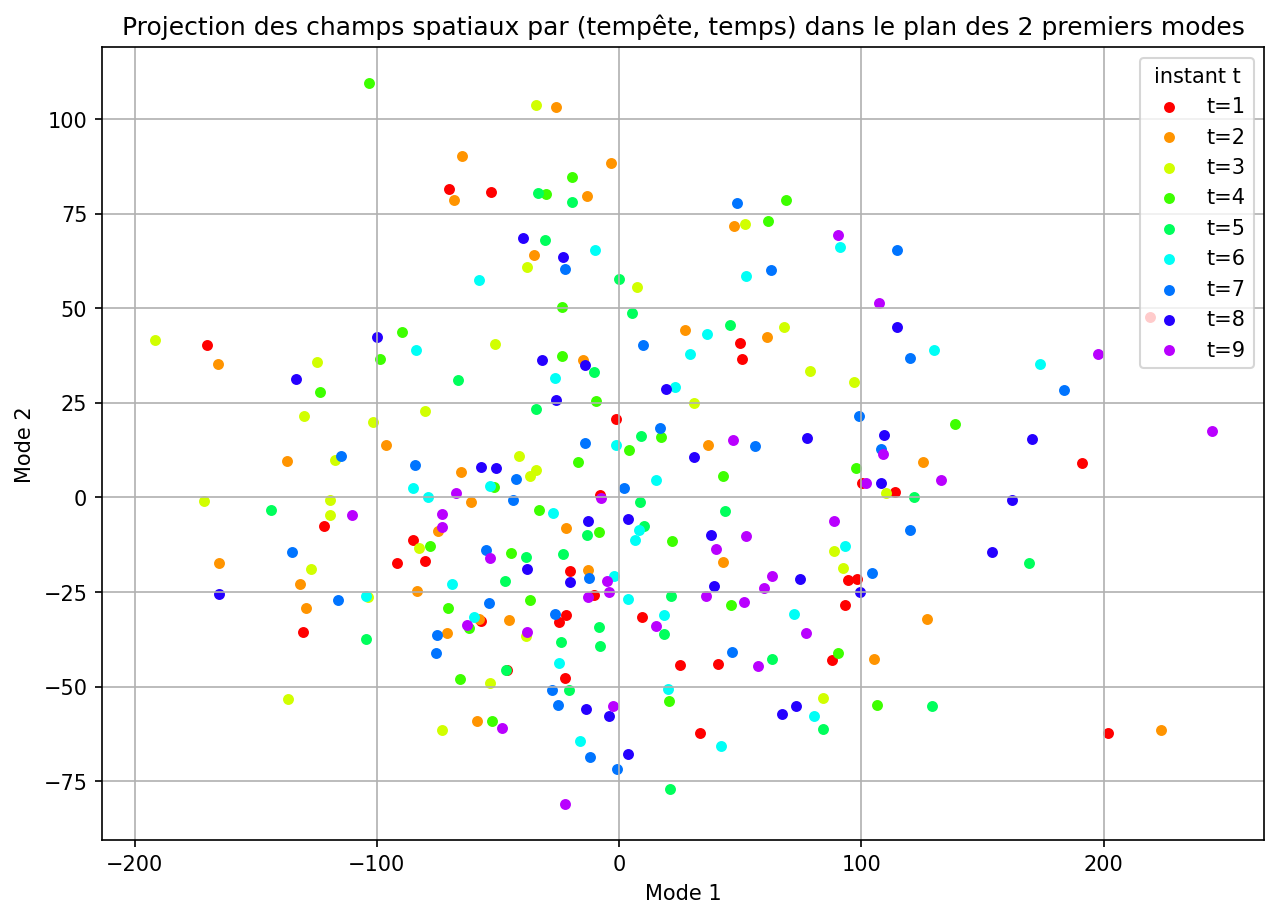

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

SAVE_DIR = "SVD_tempêtes_L2"   # adapter si besoin

# paramètres
n_storms = 32
n_t_per_storm = 9
min_rows = 15180  # taille uniforme choisie

# construire la matrice: chaque colonne = champ spatial pour (storm, t)
columns = []
order_labels = []  # pour savoir quel (storm,t) correspond à chaque colonne
for storm in range(n_storms):
    path = os.path.join(SAVE_DIR, f"storm{storm}_matrix_L2.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    data = np.load(path)
    M = data["snapshots_matrix"]  # forme (15180, 9) espérée

    # tronquer si nécessaire
    if M.shape[0] > min_rows:
        M = M[:min_rows, :]
    elif M.shape[0] < min_rows:
        raise ValueError(f"storm {storm} a {M.shape[0]} lignes < {min_rows}")

    # pour chaque temps (chaque colonne) on récupère le champ spatial
    for it in range(n_t_per_storm):
        col = M[:, it]            # vecteur (15180,)
        columns.append(col)
        order_labels.append((storm, it))  # garder indexation

# obtenir la matrice (m x n) avec m = 15180, n = 288
big_field_matrix = np.column_stack(columns)   # shape (15180, 288)

# Centrage colonne par colonne (soustraction de la moyenne spatiale)
big_field_matrix_centered = big_field_matrix - big_field_matrix.mean(axis=1, keepdims=True)


# SVD sur big_field_matrix
Uf, Df, Vtf = np.linalg.svd(big_field_matrix_centered, full_matrices=False)
# Uf (15180, k), Df (k,), Vtf (k, 288)  avec k = min(15180,288) = 288

# coordonnées des 288 snapshots dans l'espace des modes: Σ * Vt
# pour tracer les deux premiers modes :
coords = (Vtf[:2, :].T) * Df[:2]   # shape (288, 2)  (broadcast Df[:2] sur colonnes)

# plot: une couleur par time-index (0..8)
colors = plt.cm.hsv(np.linspace(0, 0.8, n_t_per_storm))
plt.figure(figsize=(10, 7), dpi=150)
for it in range(n_t_per_storm):
    pts = coords[it::n_t_per_storm, :]   # ordre : storm0_t0, storm0_t1,... so it::9 prend t=it de toutes les storms
    plt.scatter(pts[:,0], pts[:,1], s=18, color=colors[it], label=f"t={it+1}")  # label selon ton échelle t

plt.xlabel("Mode 1")
plt.ylabel("Mode 2")
plt.title("Projection des champs spatiaux par (tempête, temps) dans le plan des 2 premiers modes")
plt.legend(title="instant t")
plt.grid(True)
plt.show()


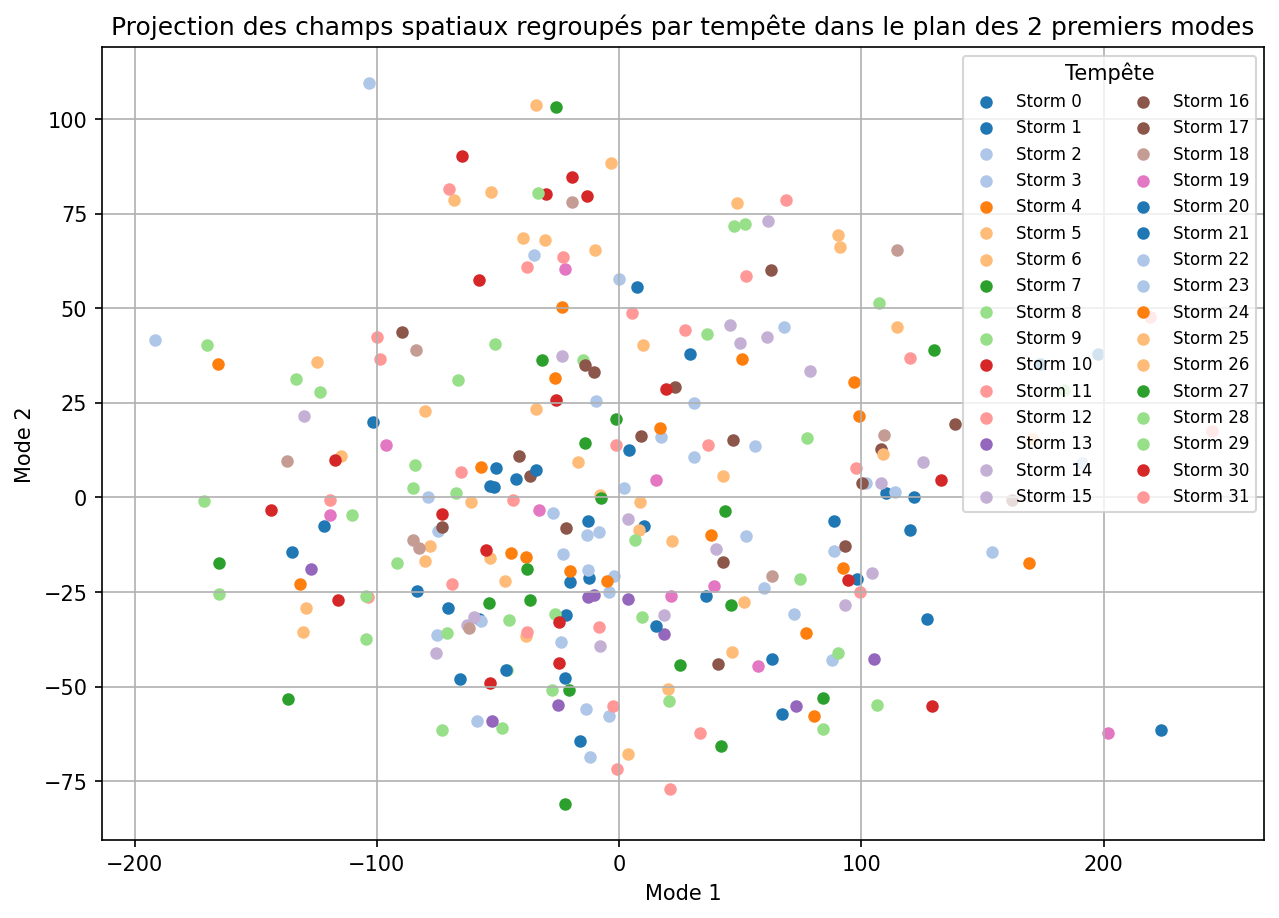

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt

SAVE_DIR = "SVD_tempêtes_L2"   # adapter si besoin

# paramètres
n_storms = 32
n_t_per_storm = 9
min_rows = 15180  # taille uniforme choisie

# construire la matrice: chaque colonne = champ spatial pour (storm, t)
columns = []
order_labels = []
for storm in range(n_storms):
    path = os.path.join(SAVE_DIR, f"storm{storm}_matrix_L2.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    data = np.load(path)
    M = data["snapshots_matrix"]  # (15180, 9)

    if M.shape[0] > min_rows:
        M = M[:min_rows, :]
    elif M.shape[0] < min_rows:
        raise ValueError(f"storm {storm} a {M.shape[0]} lignes < {min_rows}")

    for it in range(n_t_per_storm):
        col = M[:, it]
        columns.append(col)
        order_labels.append((storm, it))

# matrice complète (15180 x 288)
big_field_matrix = np.column_stack(columns)

# centrage colonne par colonne
big_field_matrix_centered = big_field_matrix - big_field_matrix.mean(axis=1, keepdims=True)

# SVD
Uf, Df, Vtf = np.linalg.svd(big_field_matrix_centered, full_matrices=False)
coords = (Vtf[:2, :].T) * Df[:2]   # (288, 2)

# --- Nouveau plot : regrouper par tempête ---
colors = plt.cm.tab20(np.linspace(0, 1, n_storms))  # palette pour 32 tempêtes
plt.figure(figsize=(10, 7), dpi=150)

for storm in range(n_storms):
    pts = coords[storm * n_t_per_storm : (storm + 1) * n_t_per_storm, :]
    plt.scatter(pts[:, 0], pts[:, 1], s=25, color=colors[storm % 20], label=f"Storm {storm}")

plt.xlabel("Mode 1")
plt.ylabel("Mode 2")
plt.title("Projection des champs spatiaux regroupés par tempête dans le plan des 2 premiers modes")
plt.legend(title="Tempête", ncol=2, fontsize=8)
plt.grid(True)
plt.show()


In [4]:
OUTPUT_DIR = "Global_SVD"
Uf, Df, Vtf = np.linalg.svd(big_field_matrix, full_matrices=False)
np.savez_compressed(os.path.join(OUTPUT_DIR, "SVD_big_field_matrix_L2.npz"), U=Uf, D=Df, Vt=Vtf)
print("SVD terminée et sauvegardée.")

SVD terminée et sauvegardée.


In [5]:
print(f"U dimensions : {Uf.shape}")
print(f"D dimensions : {Df.shape}")
print(f"Vt dimensions : {Vtf.shape}")
# Ratios d'énergie
ratios = [np.sum(Df[:i+1]**2) / np.sum(Df**2) for i in range(Df.size)]
ratios


U dimensions : (15180, 288)
D dimensions : (288,)
Vt dimensions : (288, 288)


[0.99609596,
 0.9982676,
 0.9991676,
 0.99944896,
 0.9996221,
 0.99970603,
 0.9997766,
 0.9998216,
 0.9998555,
 0.99988353,
 0.9998998,
 0.9999142,
 0.99992764,
 0.99993694,
 0.99994427,
 0.9999502,
 0.99995595,
 0.9999617,
 0.9999656,
 0.99996907,
 0.9999723,
 0.9999754,
 0.99997765,
 0.99997956,
 0.9999813,
 0.99998295,
 0.9999844,
 0.99998575,
 0.99998695,
 0.9999879,
 0.9999888,
 0.9999895,
 0.99999017,
 0.99999076,
 0.99999136,
 0.9999919,
 0.99999243,
 0.9999929,
 0.9999934,
 0.99999386,
 0.9999943,
 0.99999464,
 0.99999493,
 0.99999523,
 0.9999956,
 0.9999958,
 0.99999607,
 0.99999624,
 0.9999965,
 0.99999666,
 0.99999684,
 0.999997,
 0.9999972,
 0.9999973,
 0.99999744,
 0.99999756,
 0.9999977,
 0.9999978,
 0.9999979,
 0.99999803,
 0.99999815,
 0.9999983,
 0.99999833,
 0.99999833,
 0.9999984,
 0.99999845,
 0.9999985,
 0.99999857,
 0.9999986,
 0.9999987,
 0.99999875,
 0.99999887,
 0.9999989,
 0.999999,
 0.99999905,
 0.9999991,
 0.99999917,
 0.9999992,
 0.9999993,
 0.99999917,
 0.

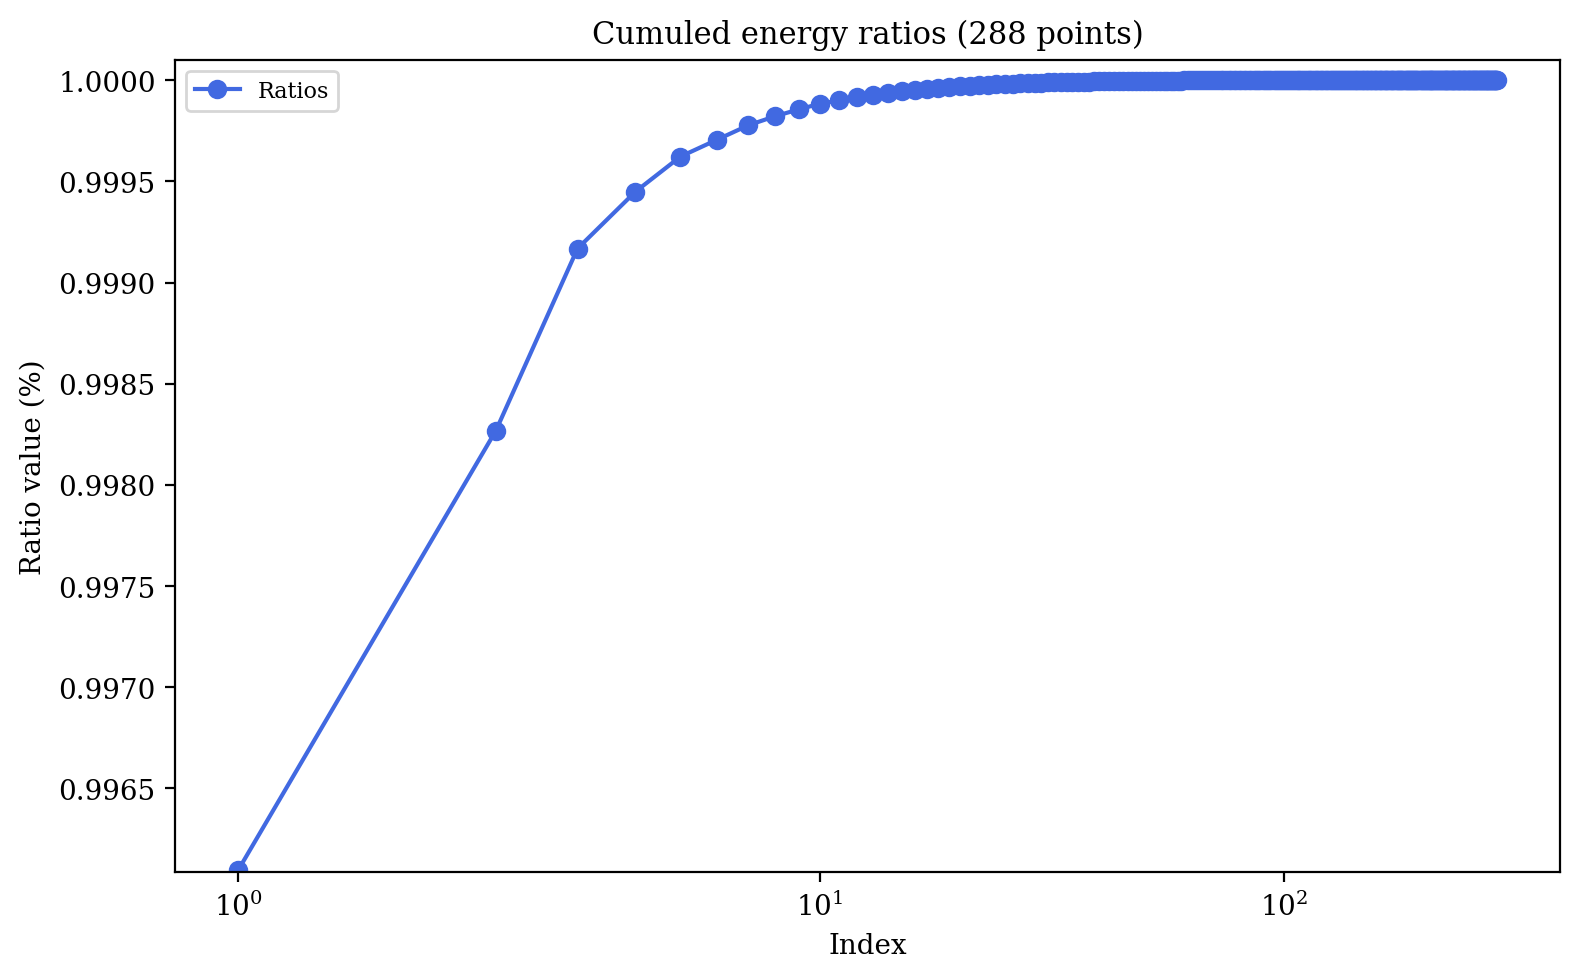

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Désactiver LaTeX et garder une police lisible
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"
})

plt.figure(figsize=(8, 5), dpi=200)

# Axe des abscisses (indices 1 à 288)
x = np.arange(1, len(ratios) + 1)

# Tracé simple de la série
plt.plot(x, ratios, 'o-', color='royalblue', label="Ratios")
plt.xscale("symlog")
#plt.yscale("log")

# Titres et labels
plt.title("Cumuled energy ratios (288 points)", fontsize=11)
plt.xlabel("Index", fontsize=10)
plt.ylabel("Ratio value (%)", fontsize=10)

# Grille et légende
plt.legend(fontsize=8)

# Optionnel : limites sur Y
plt.ylim(ratios[0]- 1e-5, 1.0001)

plt.tight_layout()
plt.show()


(15180, 288)
coeffs: (76, 288)


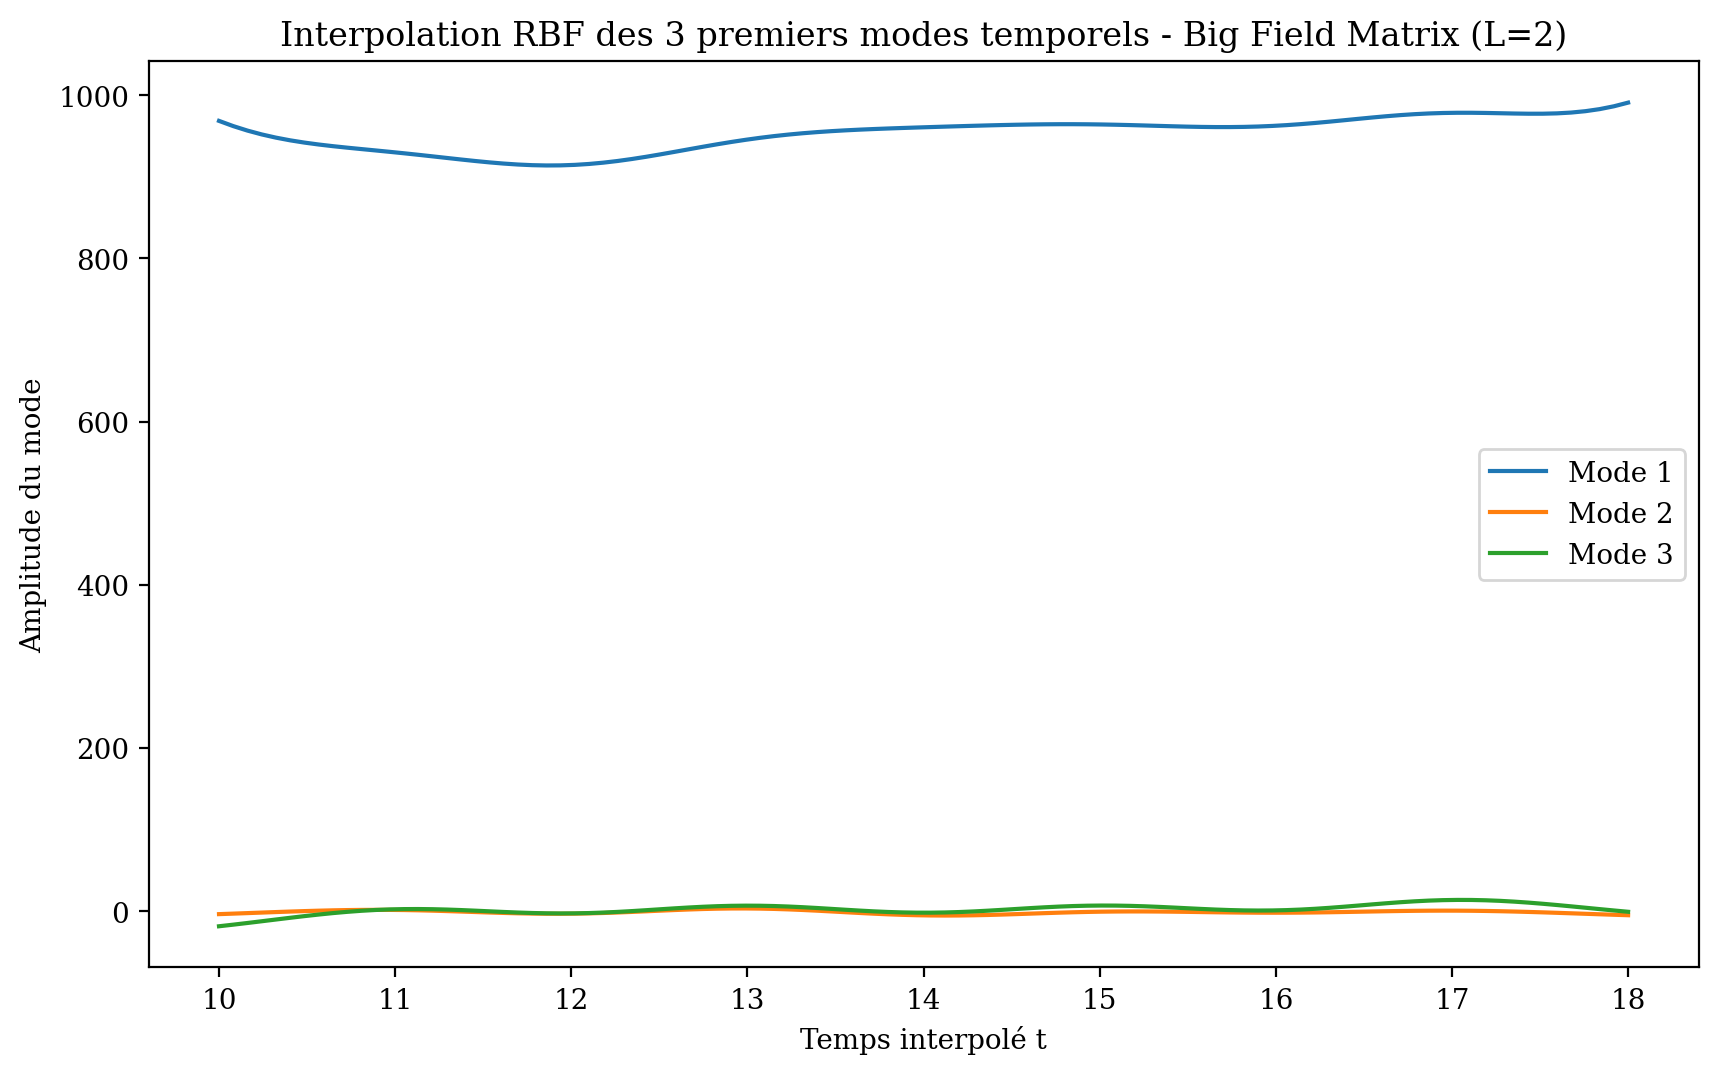

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from POD import *
from RBF import *

# Chargement de la big_field_matrix
data = np.load(os.path.join(OUTPUT_DIR, "SVD_big_field_matrix_L2.npz"))
U, D, Vt = data["U"], data["D"], data["Vt"]
big_field_matrix = U @ np.diag(D) @ Vt

print(big_field_matrix.shape)

# Paramètres temporels : 32 tempêtes × 9 snapshots (t = 10..18)
t_vals = np.arange(10, 19)
params = np.tile(t_vals, 32).reshape(-1, 1)  # shape (288, 1)

# --- POD ---
pod = POD()
pod.compute(big_field_matrix, energy_ratio=0.999999)
coeffs = pod.project(big_field_matrix)  # shape (n_modes, 288)
print("coeffs:", coeffs.shape)

# Moyenne des coefficients sur les 32 tempêtes
coeffs_mean = coeffs.reshape(coeffs.shape[0], 32, 9).mean(axis=1)  # shape (n_modes, 9)
params_unique = np.arange(10, 19).reshape(-1, 1)

# --- RBF ---
rbf = RBFInterpolator()
rbf.fit(params_unique, coeffs_mean)

# Interpolation temporelle
t_interp = np.linspace(10, 18, 100).reshape(-1, 1)
coeffs_interp = rbf.predict(t_interp)

# --- Plot des 3 premiers modes interpolés ---
plt.figure(figsize=(10,6), dpi=200)
plt.plot(t_interp, coeffs_interp[:, 0], label="Mode 1")
plt.plot(t_interp, coeffs_interp[:, 1], label="Mode 2")
plt.plot(t_interp, coeffs_interp[:, 2], label="Mode 3")
plt.xlabel("Temps interpolé t")
plt.ylabel("Amplitude du mode")
#plt.yscale("log")
plt.title("Interpolation RBF des 3 premiers modes temporels - Big Field Matrix (L=2)")
plt.legend()
plt.show()


(15180, 288)
coeffs: (12, 288)


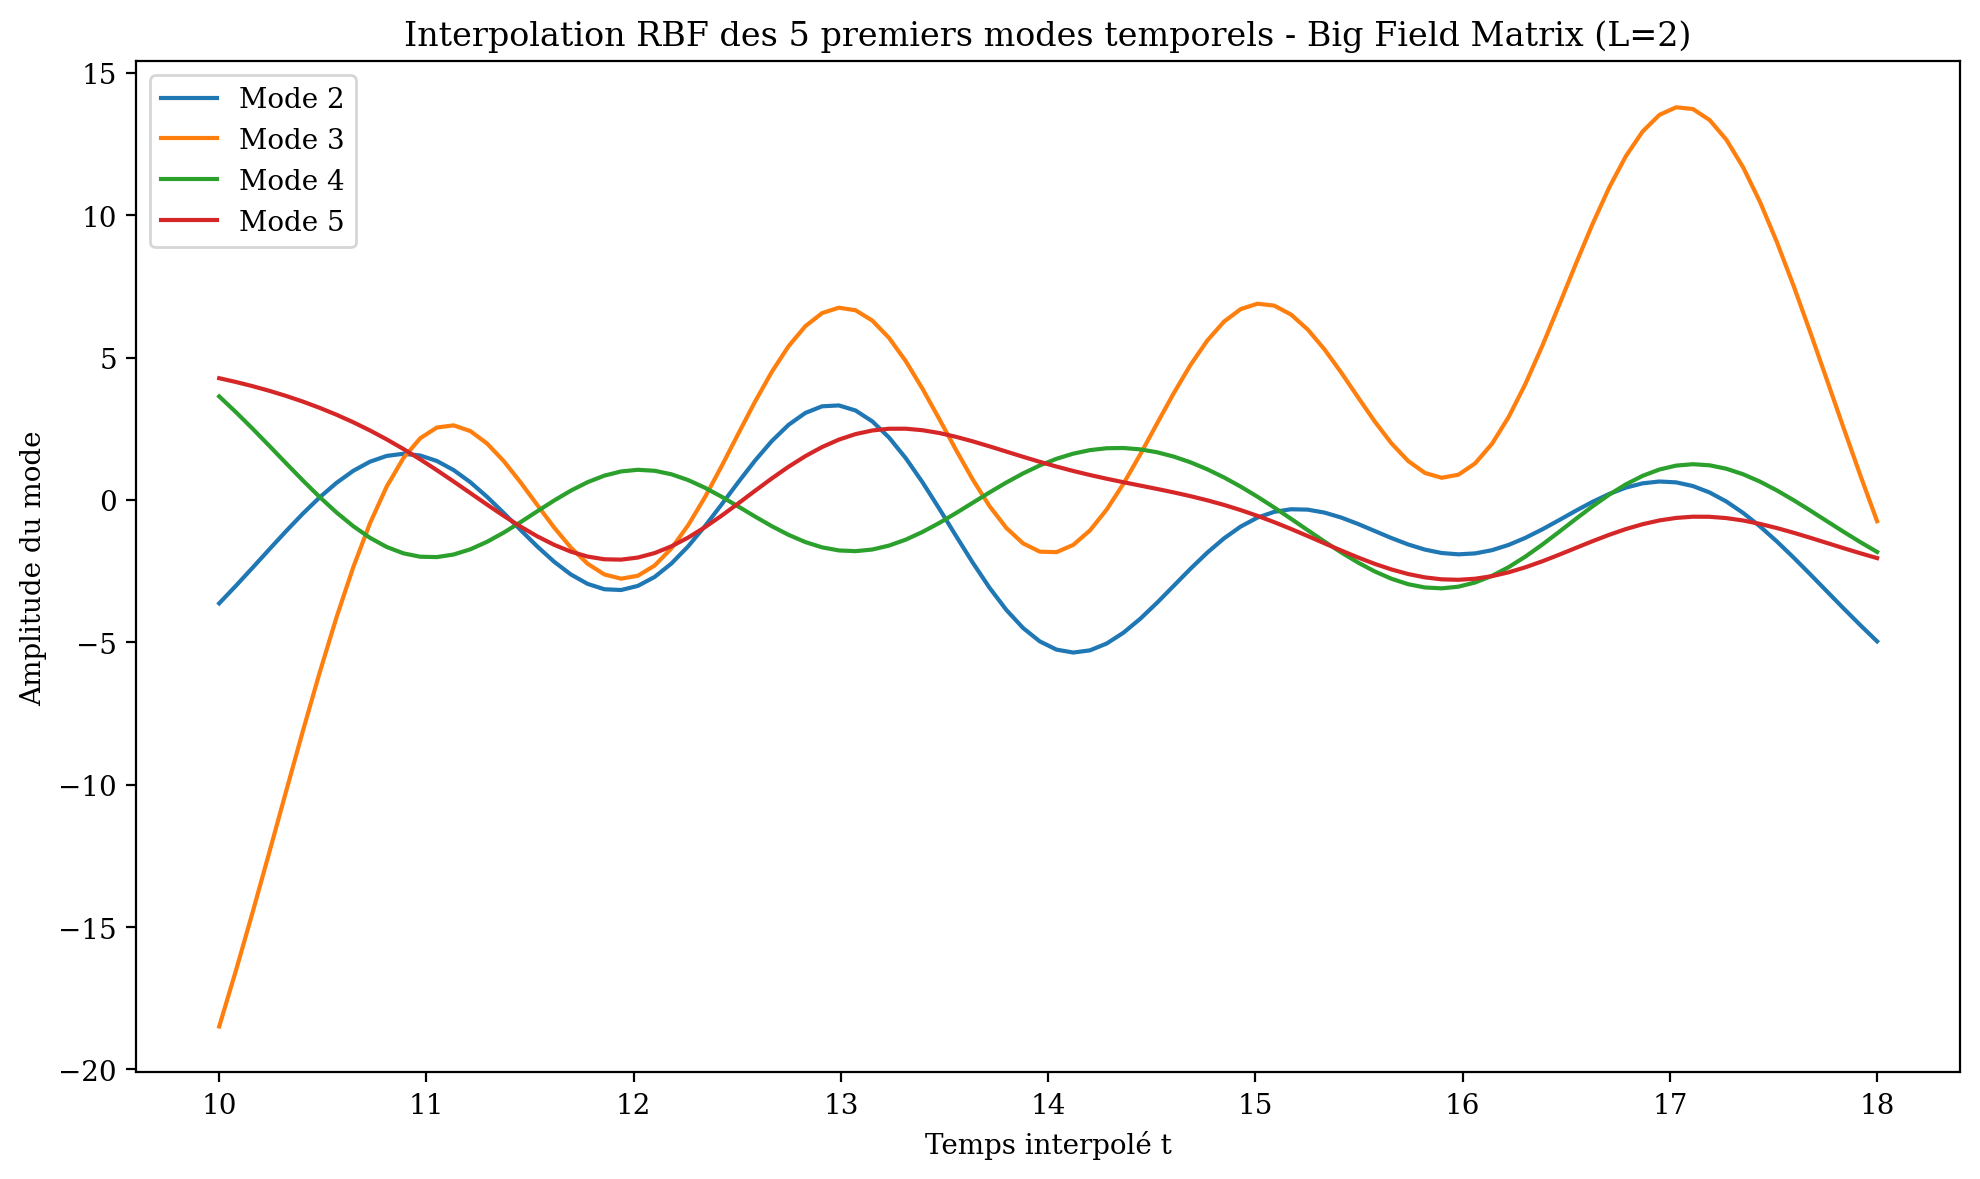

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from POD import *
from RBF import *

# === Chargement de la big_field_matrix ===
data = np.load(os.path.join(OUTPUT_DIR, "SVD_big_field_matrix_L2.npz"))
U, D, Vt = data["U"], data["D"], data["Vt"]
big_field_matrix = U @ np.diag(D) @ Vt
print(big_field_matrix.shape)

# === Paramètres temporels : 32 tempêtes × 9 snapshots ===
t_vals = np.arange(10, 19)
params = np.tile(t_vals, 32).reshape(-1, 1)  # shape (288, 1)

# === POD ===
pod = POD()
pod.compute(big_field_matrix, energy_ratio=0.9999)
coeffs = pod.project(big_field_matrix)  # shape (n_modes, 288)
print("coeffs:", coeffs.shape)

# Moyenne des coefficients sur les 32 tempêtes
coeffs_mean = coeffs.reshape(coeffs.shape[0], 32, 9).mean(axis=1)  # shape (n_modes, 9)
params_unique = np.arange(10, 19).reshape(-1, 1)

# === RBF ===
rbf = RBFInterpolator()
rbf.fit(params_unique, coeffs_mean)

# Interpolation temporelle
t_interp = np.linspace(10, 18, 100).reshape(-1, 1)
coeffs_interp = rbf.predict(t_interp)

# === Fonction de tracé ===
def plot_modes(t_interp, coeffs_interp, n_modes=3, log_scale=True):
    """
    Trace les n_modes premiers modes temporels interpolés.
    
    Args:
        t_interp (array): temps interpolés, shape (n_points, 1)
        coeffs_interp (array): coefficients interpolés, shape (n_points, n_modes_totaux)
        n_modes (int): nombre de modes à afficher
        log_scale (bool): si True, met l’axe Y en échelle logarithmique
    """
    plt.figure(figsize=(10, 6), dpi=200)
    
    for i in range(1,n_modes):
        plt.plot(t_interp, coeffs_interp[:, i], label=f"Mode {i+1}")
        #plt.yscale("log")

    
    plt.xlabel("Temps interpolé t")
    plt.ylabel("Amplitude du mode")
    plt.title(f"Interpolation RBF des {n_modes} premiers modes temporels - Big Field Matrix (L=2)")
    plt.legend()
    
    
    plt.tight_layout()
    plt.show()

# === Exemple d'utilisation ===
plot_modes(t_interp, coeffs_interp, 5)  # <-- change le nombre de modes ici


In [33]:
print(coeffs.shape)


(3, 288)


### Comparaison des deux SVD : celle sur les points et celle sur les snapshots
| Matrice                            | Lignes            | Colonnes                    | SVD donne quoi               | Points projetés                                |
| ---------------------------------- | ----------------- | --------------------------- | ---------------------------- | ---------------------------------------------- |
| `big_snapshot_matrix` (485760 × 9) | Pixels × tempêtes | 9 temps                     | Modes des 9 valeurs de temps | Chaque point = un pixel spatial (~485k points) |
| `big_field_matrix` (15180 × 288)   | Points spatiaux   | Snapshots (tempête+instant) | Modes des snapshots          | Chaque point = un snapshot entier (288 points) |

<br>
Big snapshot matrix → SVD sur les colonnes = temps, regardant corrélation entre les temps pour tous les pixels.<br>
Big field matrix → SVD sur les colonnes = snapshots entiers, regardant corrélation entre snapshots (tempêtes + instants).<br>


## Analyse des POD sur chacune des HSS (méthode agrégée ??)

In [86]:
import numpy as np
import pandas as pd
import os

# Dossier contenant les fichiers sauvegardés
SAVE_DIR = "SVD_tempêtes"
num_storms = 32

Energy_save_dir = "SVD_energy_ratio"
os.makedirs(SAVE_DIR, exist_ok=True)

# Liste pour stocker les ratios de toutes les tempêtes
all_ratios = []

for storm in range(num_storms):
    file_path = os.path.join(Energy_save_dir, f"storm{storm}_energy_ratio_L2.npz")
    if os.path.exists(file_path):
        data = np.load(file_path)
        ratios = data['ratios']
        all_ratios.append(ratios)
    else:
        print(f"Attention : fichier manquant pour la tempête {storm}")
        all_ratios.append([np.nan]*9)  # placeholder si manquant

# Conversion en DataFrame
df_ratios = pd.DataFrame(all_ratios)

# Nom des colonnes (1 à 9)
df_ratios.columns = [f"{i+1}" for i in range(df_ratios.shape[1])]

# Moyenne, médiane et percentiles
mean_vals = df_ratios.mean()
median_vals = df_ratios.median()
p5 = df_ratios.quantile(0.05)
p95 = df_ratios.quantile(0.95)

# Tableau récapitulatif
summary = pd.DataFrame({
    "Cumul (λ)": df_ratios.columns,
    "Moyenne (%)": (mean_vals*100).round(2),
    "Médiane (%)": (median_vals*100).round(2),
    "5e percentile (%)": (p5*100).round(2),
    "95e percentile (%)": (p95*100).round(2)
})

print(summary)


  Cumul (λ)  Moyenne (%)  Médiane (%)  5e percentile (%)  95e percentile (%)
1         1        99.69        99.72              99.47               99.84
2         2        99.90        99.91              99.83               99.96
3         3        99.97        99.97              99.94               99.99
4         4        99.99        99.99              99.98               99.99
5         5        99.99        99.99              99.99              100.00
6         6       100.00       100.00              99.99              100.00
7         7       100.00       100.00             100.00              100.00
8         8       100.00       100.00             100.00              100.00
9         9       100.00       100.00             100.00              100.00


In [87]:
import matplotlib
matplotlib.checkdep_usetex(True)
import os
os.environ['PATH']
import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']


usetex mode requires TeX.


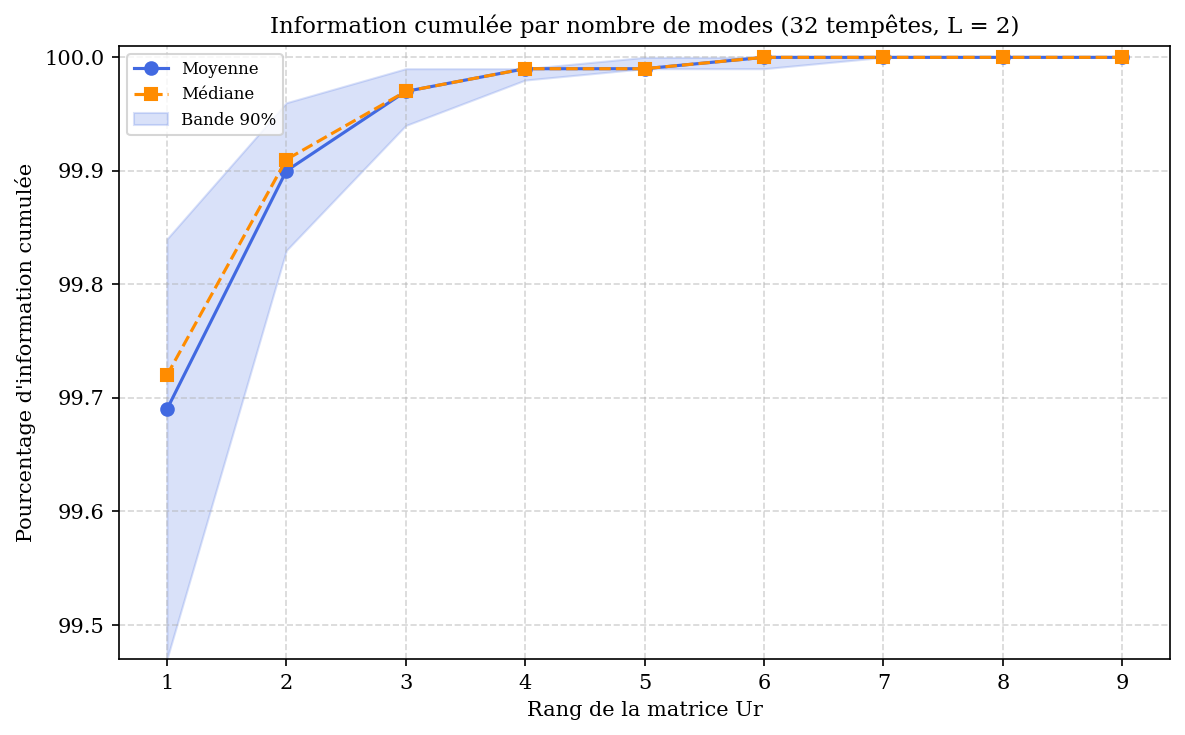

In [101]:
import matplotlib.pyplot as plt

# Désactiver LaTeX et garder une police lisible
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"
})

plt.figure(figsize=(8, 5), dpi = 150)

# Moyenne + bande [5%, 95%]
plt.plot(summary["Cumul (λ)"], summary["Moyenne (%)"], 'o-', color='royalblue', label="Moyenne")
plt.fill_between(
    summary["Cumul (λ)"],
    summary["5e percentile (%)"],
    summary["95e percentile (%)"],
    color='royalblue',
    alpha=0.2,
    label="Bande 90%"
)

# Médiane
plt.plot(summary["Cumul (λ)"], summary["Médiane (%)"], 's--', color='darkorange', label="Médiane")

# Titres et labels (sans syntaxe LaTeX)
plt.title("Information cumulée par nombre de modes (32 tempêtes, L = 2)", fontsize=11)
plt.xlabel("Rang de la matrice Ur", fontsize=10)
plt.ylabel("Pourcentage d'information cumulée", fontsize=10)

# Grille et légende
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

# Limites Y
plt.ylim(summary["5e percentile (%)"].iloc[0], 100.01)
#plt.yscale("log")

plt.tight_layout()
plt.show()


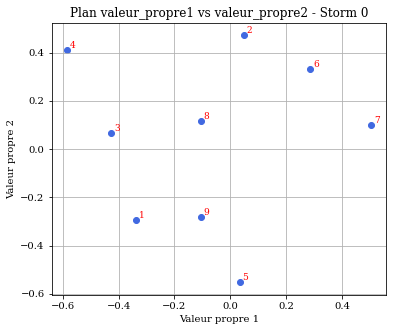

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# Chargement de la matrice compressée
data = np.load("SVD_tempêtes_L2/storm0_matrix_L2.npz")
snapshots_matrix = data["snapshots_matrix"]  # shape (num_points, 9)

# SVD
U, D, Vt = np.linalg.svd(snapshots_matrix.T, full_matrices=False)

# U a shape (9, num_points), on transpose pour avoir (num_points, 9)
points = U.T[:, :2]  # prend les deux premières colonnes (valeur propre 1 et 2)

# Affichage
plt.figure(figsize=(6,5))
plt.scatter(points[:,0], points[:,1], color='royalblue')

# Annoter avec t = 10..18
for i, t_val in enumerate(range(10, 19)):
    x, y = points[i,0], points[i,1]
    plt.text(x + 0.01, y + 0.01, str(t_val-9), fontsize=9, color='red')

plt.xlabel("Valeur propre 1")
plt.ylabel("Valeur propre 2")
plt.title("Plan valeur_propre1 vs valeur_propre2 - Storm 0")
plt.grid(True)
plt.show()


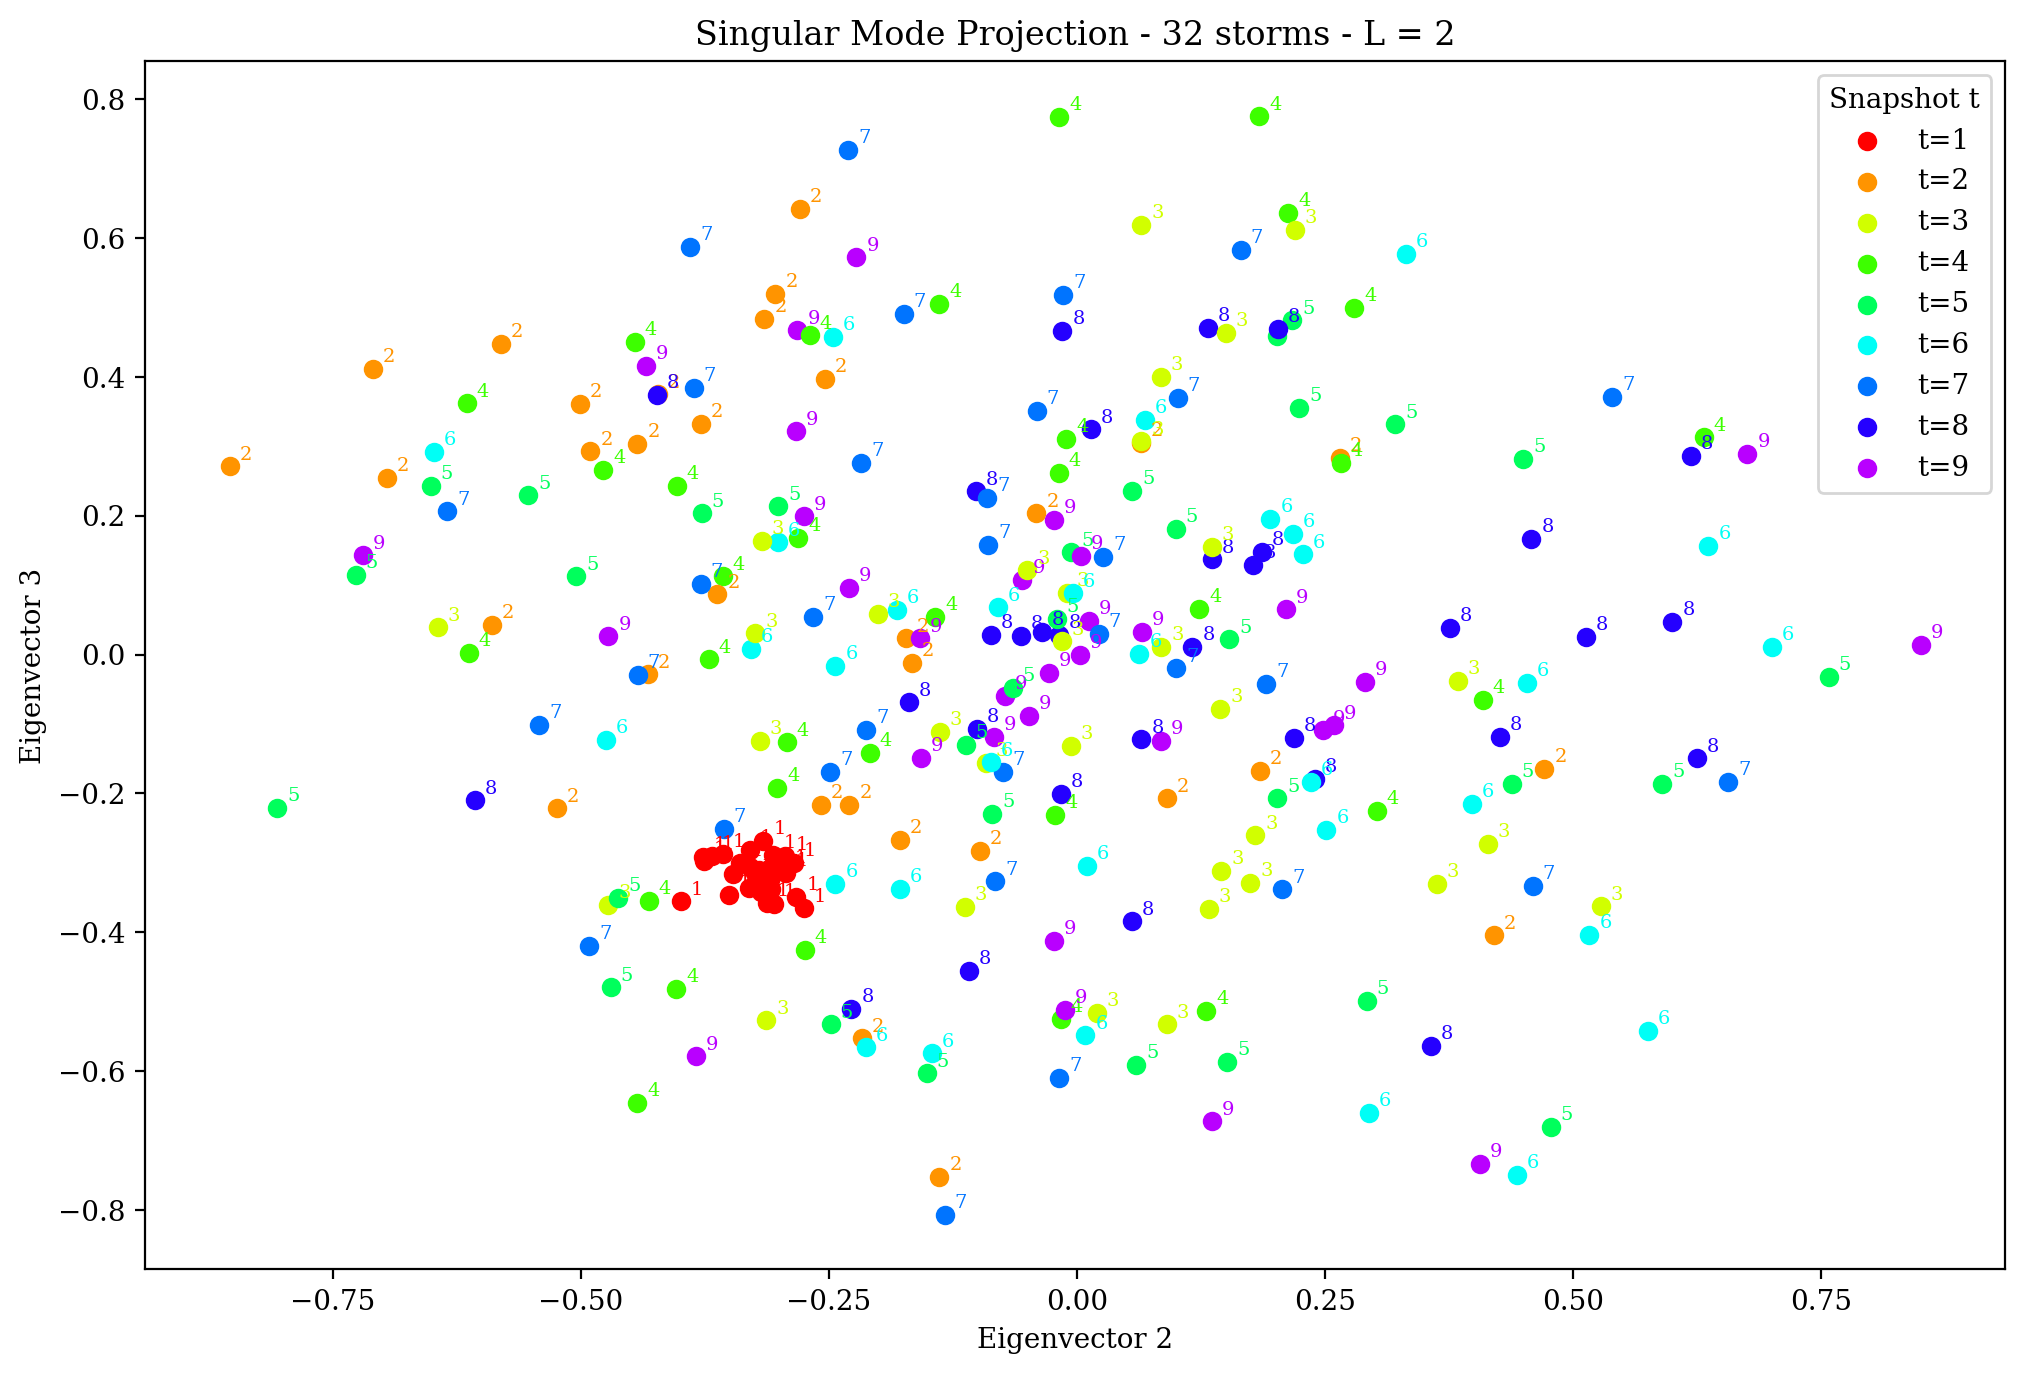

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import os

SAVE_DIR = "SVD_tempêtes_L2"

# Palette de couleurs pour les snapshots t=10..18
colors = plt.cm.hsv(np.linspace(0, 0.8, 9)) 

plt.figure(figsize=(12,8), dpi=200)

for storm in range(32):
    data = np.load(os.path.join(SAVE_DIR, f"storm{storm}_matrix_L2.npz"))
    snapshots_matrix = data["snapshots_matrix"]
    
    # SVD sur la transposée pour avoir les snapshots sur les lignes
    U, D, Vt = np.linalg.svd(snapshots_matrix.T, full_matrices=False)
    points = U.T[:, [1,2]]  # deux premières composantes

    # tracer chaque point avec sa couleur selon t
    for i, t_val in enumerate(range(10, 19)):
        x, y = points[i,0], points[i,1]
        plt.scatter(x, y, color=colors[i], label=f"t={t_val -9}" if storm==0 else "")
        plt.text(x + 0.01, y + 0.01, str(t_val-9), fontsize=7, color=colors[i])

plt.xlabel("Eigenvector 2")
plt.ylabel("Eigenvector 3")
plt.title("Singular Mode Projection - 32 storms - L = 2")

# Légende pour t seulement (éviter doublons)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Snapshot t")

plt.show()


Text(0.5, 1.0, 'Spread of storms over time')

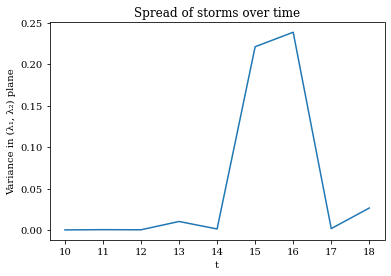

In [108]:
variances = []
for i, t_val in enumerate(range(10,19)):
    x = points[i,0]
    y = points[i,1]
    var_t = np.var([x, y])
    variances.append(var_t)

plt.plot(range(10,19), variances)
plt.xlabel("t")
plt.ylabel("Variance in (λ₁, λ₂) plane")
plt.title("Spread of storms over time")


In [103]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

SAVE_DIR = "SVD_tempêtes"

# Liste pour stocker les spectres
all_ratios = []

# Charger les 32 fichiers de ratios
for i in range(32):
    path = os.path.join(Energy_save_dir, f"storm{i}_energy_ratio_L2.npz")
    data = np.load(path)
    ratios = data["ratios"]
    all_ratios.append(ratios)

# Convertir en matrice numpy (32×9)
spectra_matrix = np.array(all_ratios)
print(spectra_matrix.shape)  # (32, 9)


(32, 9)


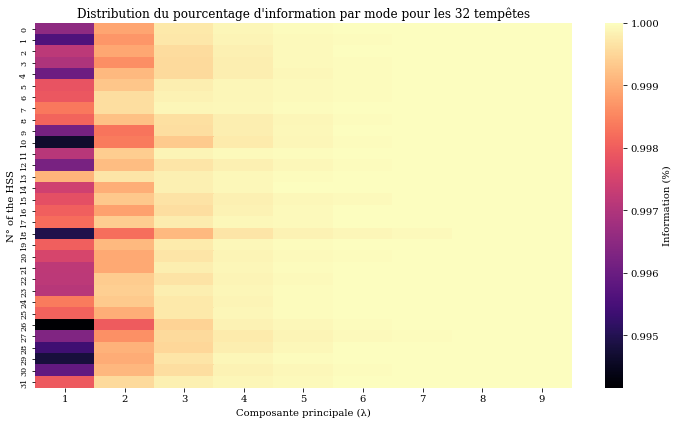

In [104]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    spectra_matrix,
    cmap="magma",            # ou "viridis", "coolwarm", "plasma", etc.
    annot=False,
    cbar_kws={'label': 'Information (%)'}
)

plt.xlabel("Composante principale (λ)")
plt.ylabel("N° of the HSS")
plt.title("Distribution du pourcentage d'information par mode pour les 32 tempêtes")
plt.xticks(ticks=np.arange(9)+0.5, labels=np.arange(1, 10))
plt.yticks(ticks=np.arange(32)+0.5, labels=[f"{i}" for i in range(32)], fontsize=8)
plt.tight_layout()
plt.show()


## Prédiction météorologique à L fixé
On va recrée une matrice enregistrer qui a compilé les 32 tempêtes à Lfixé. Sauf que cette fois si, on ne prendra que 8 <br>
snapshots par tempêtes (au lieu de 9 avant). On va donc stocker 256 snapshots (32x8) stockés dans une matrice de taille <br> 
(15180, 256). On effectue ensuite une POD sur cette matrice et effectuer des prédictions pour chaque tempête au temps t = 9, <br>
prédictions qu'on pourra comparer avec notre 9ème snapshot qui nous servira de GroundTruth. On pourra donc calculer 32 erreurs <br>
et analyser les performances de la POD dans un cadre prédictif. 

In [13]:
import numpy as np
import os

SAVE_DIR = "SVD_tempêtes_L2"   # dossier contenant les matrices individuelles
OUTPUT_PATH = "Global_SVD_pred/big_field_matrix_train_L2.npz"  # fichier de sortie


# paramètres
n_storms = 32
n_t_per_storm_total = 9
n_t_used = 8      # on ne prend que les 8 premiers snapshots
min_rows = 15180  # taille uniforme choisie

# construire la matrice: chaque colonne = champ spatial pour (storm, t)
columns = []
order_labels = []  # pour savoir quel (storm,t) correspond à chaque colonne

for storm in range(n_storms):
    path = os.path.join(SAVE_DIR, f"storm{storm}_matrix_L2.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    data = np.load(path)
    M = data["snapshots_matrix"]  # forme attendue (15180 ou 15240, 9)

    # tronquer si nécessaire
    if M.shape[0] > min_rows:
        M = M[:min_rows, :]
    elif M.shape[0] < min_rows:
        raise ValueError(f"storm {storm} a {M.shape[0]} lignes < {min_rows}")

    # pour chaque temps utilisé (colonnes 0→7) on récupère le champ spatial
    for it in range(n_t_used):
        col = M[:, it]            # vecteur (15180,)
        columns.append(col)
        order_labels.append((storm, it))  # garder indexation

# obtenir la matrice (m x n) avec m = 15180, n = 32*8 = 256
big_field_matrix_train = np.column_stack(columns)
print("big_field_matrix_train.shape =", big_field_matrix_train.shape)

big_field_matrix_train = big_field_matrix_train - big_field_matrix_train.mean(axis=1, keepdims=True)

# sauvegarde
np.savez_compressed(OUTPUT_PATH,
                    big_field_matrix=big_field_matrix_train,
                    order_labels=np.array(order_labels))
print(f"Matrice sauvegardée sous {OUTPUT_PATH}")



big_field_matrix_train.shape = (15180, 256)
Matrice sauvegardée sous Global_SVD_pred/big_field_matrix_train_L2.npz


### Projection de l'ensemble des snapshots 
On se place dans le plan (espace propre 1, espace propre 2) et on projette les coordonnées de l'ensemble des snapshots pour voir si un patterne se dégage. <br>
Cela ne semble pas être le cas, et ces deux esaces propres semblent bien représenter l'ensemble de l'informatio de pas l'homogénité de la répartition de ces points. 

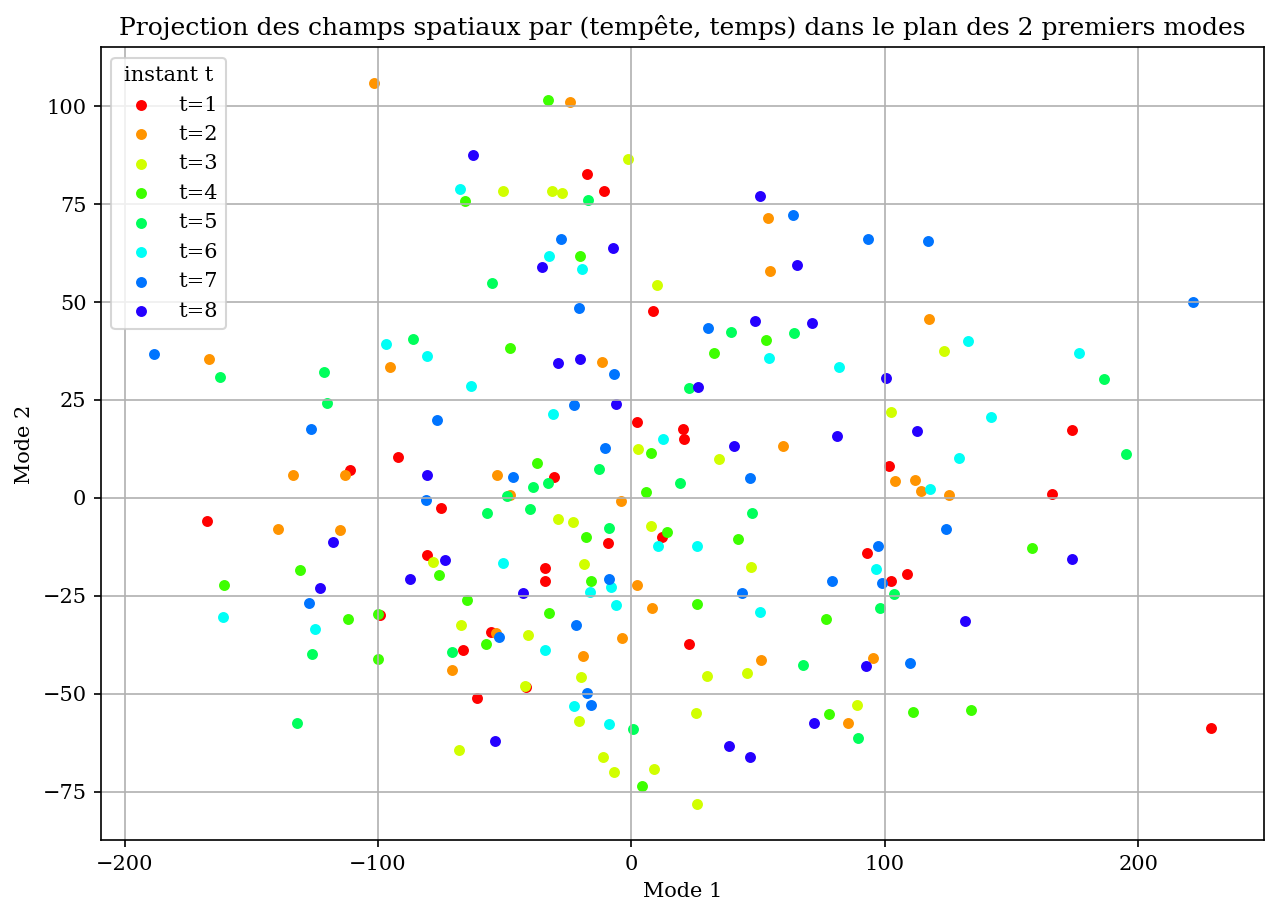

In [14]:

# SVD sur big_field_matrix
Uf, Df, Vtf = np.linalg.svd(big_field_matrix_train, full_matrices=False)
# Uf (15180, k), Df (k,), Vtf (k, 288)  avec k = min(15180,288) = 288

# coordonnées des 288 snapshots dans l'espace des modes: Σ * Vt
# pour tracer les deux premiers modes :
coords = (Vtf[:2, :].T) * Df[:2]   # shape (288, 2)  (broadcast Df[:2] sur colonnes)

# plot: une couleur par time-index (0..8)
colors = plt.cm.hsv(np.linspace(0, 0.8, n_t_per_storm))
plt.figure(figsize=(10, 7), dpi=150)
for it in range(n_t_used):
    pts = coords[it::n_t_per_storm, :]   # ordre : storm0_t0, storm0_t1,... so it::9 prend t=it de toutes les storms
    plt.scatter(pts[:,0], pts[:,1], s=18, color=colors[it], label=f"t={it+1}")  # label selon ton échelle t

plt.xlabel("Mode 1")
plt.ylabel("Mode 2")
plt.title("Projection des champs spatiaux par (tempête, temps) dans le plan des 2 premiers modes")
plt.legend(title="instant t")
plt.grid(True)
plt.show()

### Annexe prédiction

#### Prédiction sur l'ensemble des 32 tempête à t = 9

In [119]:
import numpy as np
from POD import POD
from RBF import RBFInterpolator

# indices pour une tempête donnée
storm_idx = 0  # changer de 0 à 31 pour chaque tempête
n_t_used = 8   # on utilise les 8 premiers snapshots
n_t_total = 9  # total snapshots par tempête

# Extraire les snapshots de la tempête
start_col = storm_idx * n_t_total
snapshots_storm = big_field_matrix[:, start_col:start_col+n_t_used]  # shape (15180, 8)

# --- POD ---
pod = POD()
pod.compute(snapshots_storm, energy_ratio=0.9999)
coeffs = pod.project(snapshots_storm)  # shape (n_modes, 8)

# --- RBF ---
params_train = np.arange(10, 18).reshape(-1, 1)  # t = 10..17
rbf = RBFInterpolator()
rbf.fit(params_train, coeffs)

# --- Prédiction du 9ème snapshot ---
t_predict = np.array([[18]])
coeffs_predict = rbf.predict(t_predict)  # shape (1, n_modes)

# Reconstruction du champ spatial prédit
state_predict = pod.reconstruct(coeffs_predict.T)  # shape (15180,)
print("state_predict.shape:", state_predict.shape)


state_predict.shape: (15180, 1)


#### Prédiction pour une tempête donnée à t = 9

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import os
from POD import POD
from RBF import RBFInterpolator

SAVE_DIR = "SVD_tempêtes_L2"
storm_idx = 0  # numéro de la tempête
n_t_used = 8   # utiliser les 8 premiers snapshots
n_t_total = 9  # total snapshots par tempête
min_rows = 15180  # tronquer si besoin

# --- Charger la tempête ---
path = os.path.join(SAVE_DIR, f"storm{storm_idx}_matrix_L2.npz")
data = np.load(path)
M = data["snapshots_matrix"]
if M.shape[0] > min_rows:
    M = M[:min_rows, :]
elif M.shape[0] < min_rows:
    raise ValueError(f"Tempête {storm_idx} a {M.shape[0]} lignes < {min_rows}")

snapshots_train = M[:, :n_t_used]   # 8 premiers snapshots
snapshot_true = M[:, n_t_total-1]   # 9ème snapshot réel

snapshot_true.shape

(15180,)

### Affichage des prédictions et différences

Prédiction HSS n°3


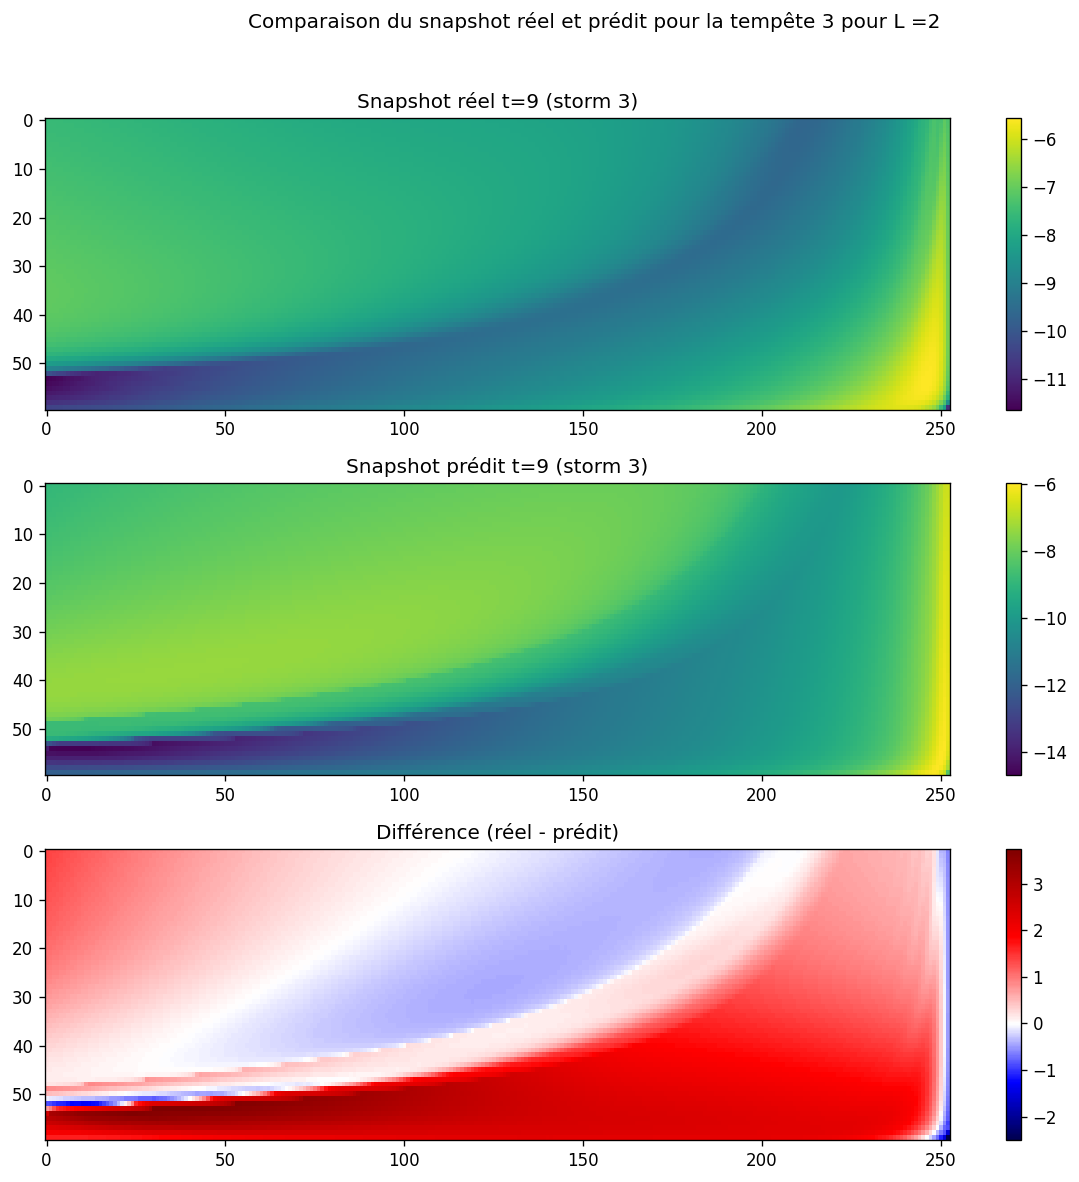

--------------------------------------------------------------------------------------------
Prédiction HSS n°28


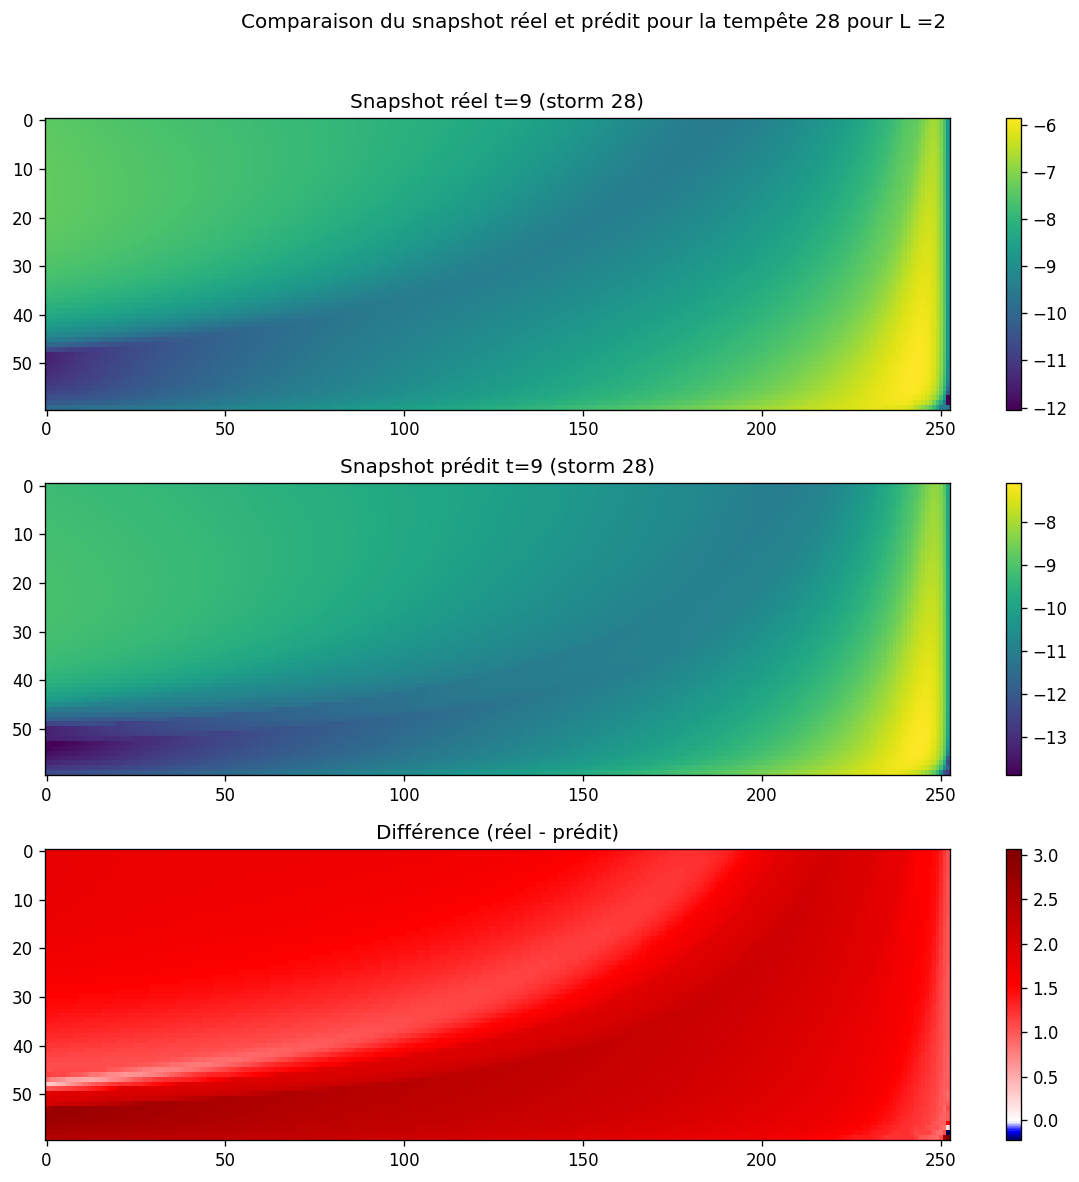

--------------------------------------------------------------------------------------------
Prédiction HSS n°30


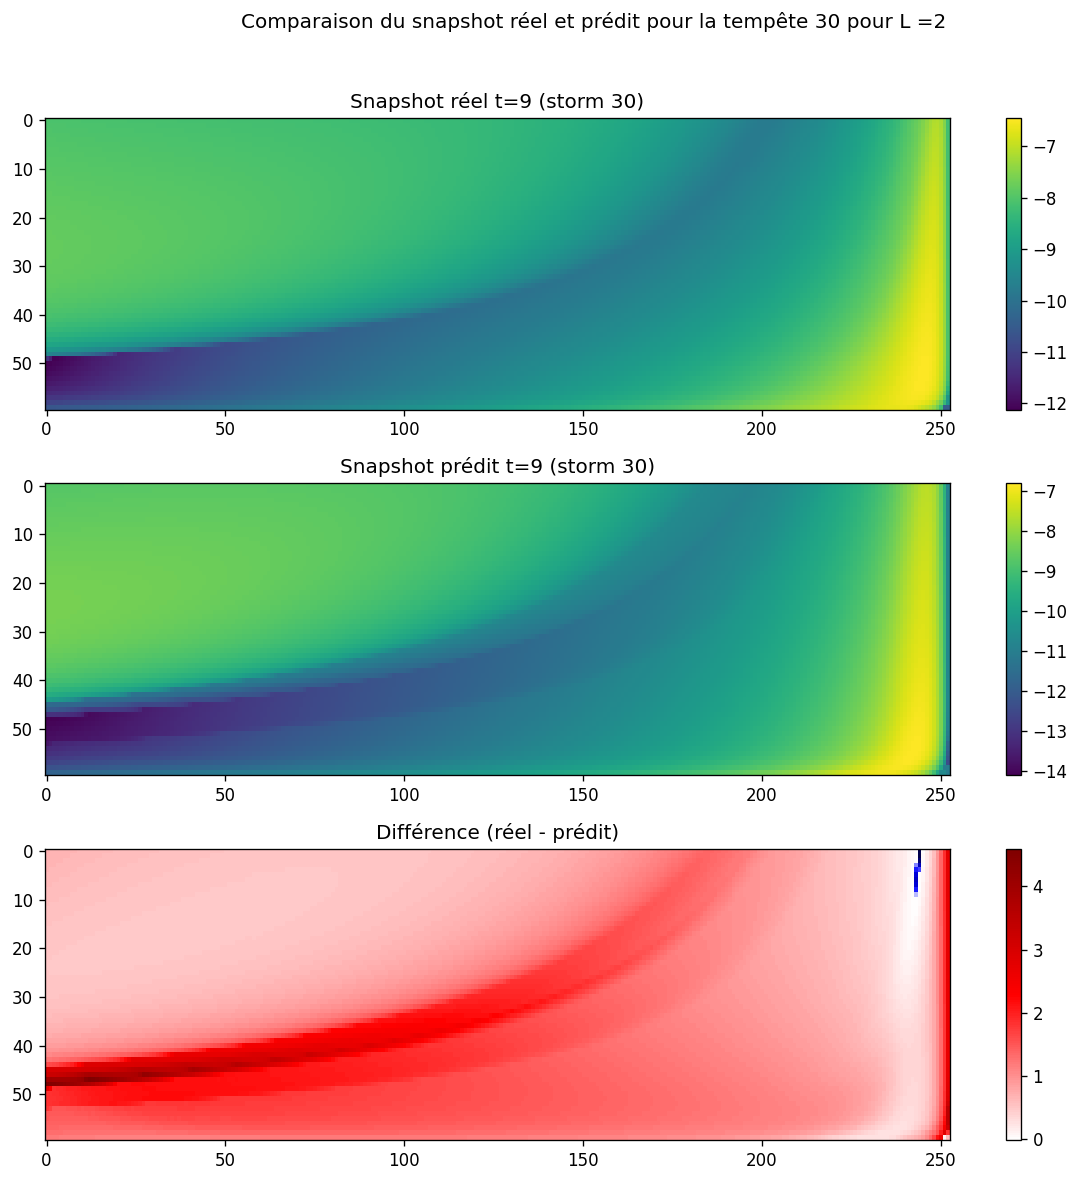

In [5]:
from POD import *
from RBF import *
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

def plot_pred_differences(storm_idx) :
    SAVE_DIR = "SVD_tempêtes_L2"
    #storm_idx = 0
    n_t_used = 8
    n_t_total = 9
    min_rows = 15180

    # --- Charger la tempête ---
    path = os.path.join(SAVE_DIR, f"storm{storm_idx}_matrix_L2.npz")
    data = np.load(path)
    snapshots_matrix = data["snapshots_matrix"]

    if snapshots_matrix.shape[0] > min_rows:
        snapshots_matrix = snapshots_matrix[:min_rows, :]
    elif snapshots_matrix.shape[0] < min_rows:
        raise ValueError(f"Tempête {storm_idx} a {snapshots_matrix.shape[0]} lignes < {min_rows}")

    # --- Entraînement sur les 8 premiers snapshots ---
    snapshots_train = snapshots_matrix[:, :n_t_used]
    snapshot_true = snapshots_matrix[:, n_t_total-1]  # t = 18

    # --- POD + RBF ---
    params = np.linspace(10, 17, n_t_used).reshape(-1, 1)
    pod = POD()
    pod.compute(snapshots_train, energy_ratio=0.999)
    coeffs = pod.project(snapshots_train)

    rbf = RBFInterpolator()
    rbf.fit(params, coeffs)

    # --- Prédiction du snapshot à t=18 ---
    t_predict = np.array([[18]])
    coeffs_pred = rbf.predict(t_predict)
    state_pred = pod.reconstruct(coeffs_pred)

    # --- Visualisation réelle vs prédite + différence ---
    plt.figure(figsize=(10, 10), dpi=120)

    # Snapshot réel
    plt.subplot(3, 1, 1)
    plt.imshow(np.rot90(snapshot_true.reshape(253, 60), k=1), cmap='viridis', aspect='auto')
    plt.title(f"Snapshot réel t=9 (storm {storm_idx})")
    plt.colorbar()

    # Snapshot prédit
    plt.subplot(3, 1, 2)
    plt.imshow(np.rot90(state_pred.reshape(253, 60), k=1), cmap='viridis', aspect='auto')
    plt.title(f"Snapshot prédit t=9 (storm {storm_idx})")
    plt.colorbar()

    diff = (snapshot_true - state_pred).reshape(253, 60)
    diff_rot = np.rot90(diff, k=1)

    # Normalisation centrée sur zéro
    norm = mcolors.TwoSlopeNorm(vmin=diff_rot.min(), vcenter=0, vmax=diff_rot.max())

    plt.subplot(3, 1, 3)
    plt.imshow(diff_rot, cmap='seismic', aspect='auto', norm=norm)
    plt.title("Différence (réel - prédit)")
    plt.colorbar()

    plt.suptitle(f"Comparaison du snapshot réel et prédit pour la tempête {storm_idx} pour L =2")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
list_num = [3, 28, 30]
for num in list_num:
    print(f"Prédiction HSS n°{num}")
    plot_pred_differences(num)
    if num != 30 : 
        print("--------------------------------------------------------------------------------------------")

## Évaluation du modèle prédictif à t = 9

In [13]:
import numpy as np
import os
from POD import POD
from RBF import RBFInterpolator

def evaluate_storm_prediction(storm_idx):
    SAVE_DIR = "SVD_tempêtes_L2"
    n_t_used = 8
    n_t_total = 9
    min_rows = 15180

    # --- Charger la tempête ---
    path = os.path.join(SAVE_DIR, f"storm{storm_idx}_matrix_L2.npz")
    data = np.load(path)
    snapshots_matrix = data["snapshots_matrix"]

    if snapshots_matrix.shape[0] > min_rows:
        snapshots_matrix = snapshots_matrix[:min_rows, :]
    elif snapshots_matrix.shape[0] < min_rows:
        raise ValueError(f"Tempête {storm_idx} a {snapshots_matrix.shape[0]} lignes < {min_rows}")

    # --- Entraînement sur les 8 premiers snapshots ---
    snapshots_train = snapshots_matrix[:, :n_t_used]
    snapshot_true = snapshots_matrix[:, n_t_total-1]  # snapshot réel à t = 18

    # --- POD + RBF ---
    params = np.linspace(10, 17, n_t_used).reshape(-1, 1)
    pod = POD()
    pod.compute(snapshots_train, energy_ratio=0.999)
    coeffs = pod.project(snapshots_train)

    rbf = RBFInterpolator()
    rbf.fit(params, coeffs)

    # --- Prédiction du snapshot à t=18 ---
    t_predict = np.array([[18]])
    coeffs_pred = rbf.predict(t_predict)
    state_pred = pod.reconstruct(coeffs_pred)

    # --- Calcul des erreurs ---
    diff = snapshot_true - state_pred.ravel()
    err_rel = np.linalg.norm(diff) / np.linalg.norm(snapshot_true)
    score = max(0, 100 * (1 - err_rel))

    abs_diff = np.abs(diff)/ np.abs(snapshot_true)
    mean_err = abs_diff.mean()
    median_err = np.median(abs_diff)
    p5 = np.percentile(abs_diff, 5)
    p95 = np.percentile(abs_diff, 95)

    stats = {
        "storm": storm_idx,
        "relative_error": err_rel,
        "score": score,
        "mean_error": mean_err,
        "median_error": median_err,
        "p5_error": p5,
        "p95_error": p95
    }

    return stats


In [14]:
import pandas as pd

results = [evaluate_storm_prediction(i) for i in range(32)]
df_results = pd.DataFrame(results)
df_results


,storm,relative_error,score,mean_error,median_error,p5_error,p95_error
0,0,0.136595,86.340505,0.122671,0.135127,0.019682,0.181632
1,1,0.059903,94.009699,0.053565,0.059638,0.004122,0.090720
2,2,0.159781,84.021912,0.123468,0.088292,0.014640,0.293123
3,3,0.154511,84.548918,0.108279,0.059058,0.006162,0.307536
4,4,0.121112,87.888783,0.088833,0.076986,0.004234,0.195589
5,5,0.223328,77.667231,0.196776,0.167712,0.103203,0.374117
6,6,0.349631,65.036919,0.323393,0.262607,0.187888,0.632667
7,7,0.170286,82.971360,0.160721,0.146188,0.055313,0.332254
8,8,0.031226,96.877371,0.020698,0.011707,0.000800,0.076594
9,9,0.355376,64.462393,0.327316,0.319851,0.033120,0.694668


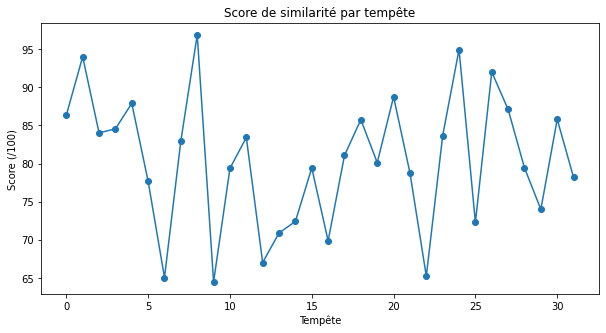

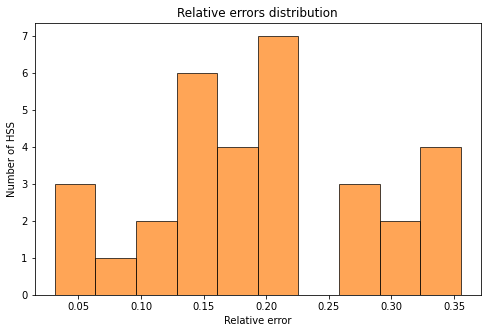

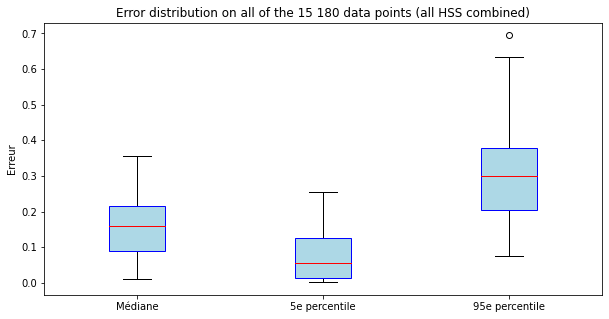

In [16]:
import matplotlib.pyplot as plt

# --- 1. Score global par tempête ---
plt.figure(figsize=(10, 5))
plt.plot(df_results["storm"], df_results["score"], marker='o', color='tab:blue')
plt.xlabel("Tempête")
plt.ylabel("Score (/100)")
plt.title("Score de similarité par tempête")
plt.show()

# --- 2. Distribution des erreurs relatives ---
plt.figure(figsize=(8, 5))
plt.hist(df_results["relative_error"], bins=10, edgecolor='k', alpha=0.7, color='tab:orange')
plt.xlabel("Relative error")
plt.ylabel("Number of HSS")
plt.title("Relative errors distribution")
plt.show()

# --- 3. Boîte à moustaches des percentiles d'erreur ---
plt.figure(figsize=(10, 5))
plt.boxplot(
    [
        df_results["median_error"],
        df_results["p5_error"],
        df_results["p95_error"]
    ],
    labels=["Médiane", "5e percentile", "95e percentile"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red")
)
plt.ylabel("Error")
plt.title("Error distribution on all of the 15 180 data points (all HSS combined)")
plt.show()

